In [ ]:
import scanpy as sc
import pandas as pd
import numpy as np
import networkx as nx
import os
import re
from scipy.spatial import distance
import math
from scipy.cluster import hierarchy
from argparse import Namespace
import matplotlib.pyplot as plt
import oslom
import scipy.stats as stats
import scipy
import random

sc.set_figure_params(dpi=80)

import seaborn as sns
plt.rcParams['axes.grid'] = False

import matplotlib
from matplotlib.gridspec import GridSpec
from datetime import datetime
from matplotlib.ticker import FixedLocator, FixedFormatter
from tqdm import tqdm
matplotlib.rcParams["text.usetex"] = False
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
from matplotlib import rc
rc('font',**{'family':'sans-serif','sans-serif':['DejaVu Sans']})


In [ ]:
import cupy
import cuml
import cupyx
import cugraph

General utilities

In [ ]:
import importlib.util
import sys

def lazy_import(module_name, path_to_file):
    spec = importlib.util.spec_from_file_location(module_name,path_to_file)
    foo = importlib.util.module_from_spec(spec)
    sys.modules[module_name] = foo
    spec.loader.exec_module(foo)
    return foo

utils_dir = "../../utils"
general_utils =  lazy_import("general_utils",os.path.join(utils_dir, "general_utils.py"))
anndata_utils = lazy_import("anndata_utils",os.path.join(utils_dir, "anndata_utils.py"))
plotting_functions = lazy_import("plotting_functions",os.path.join(utils_dir, "plotting_functions.py"))
neighborhood_utils = lazy_import("neighborhood_utils",os.path.join(utils_dir, "neighborhood_utils.py"))
thresholding_functions = lazy_import("thresholding_functions",os.path.join(utils_dir, "thresholding_functions.py"))
gene_signatures = lazy_import("gene_signatures",os.path.join(utils_dir, "gene_signatures.py"))

from general_utils import ismember, grep, grep_exclude, flatten, write_object, read_object
from anndata_utils import query_region, random_adata_subset, filter_coordinates, get_gene
from plotting_functions import plot_individual_category, plot_gene, make_density_map, get_custom_legend_patches, get_custom_legend_circles, pseudo_color, get_pseudo_colors
from plotting_functions import plot_nuclei_continuum_by_cell, plot_nuclei_continuum_by_box, plot_nuclei_categories_by_box
from neighborhood_utils import create_diagonal_matrix, get_average_neighborhood_expression, get_neighborhood_fraction, get_neighborhood_count, get_total_neighborhood_expression
from neighborhood_utils import neighbors_gpu, get_cugraph_from_csr_matrix, get_cugraph_from_array, get_spatial_knn, compute_sample_neighborhoods
from thresholding_functions import threshold_triangle, threshold_otsu
from gene_signatures import attach_custom_signature


### Import RL pairs

In [ ]:
import itertools
rl_database = pd.read_csv('../support/CellChatDB.ligrec.mouse.csv', sep = ",", index_col = 0)
ligands = [re.split("_", x) for x in rl_database.iloc[:,0]]
receptors = [re.split("_", x) for x in rl_database.iloc[:,1]]

ligand_receptor_pairs = []
for ligand_collection, receptor_collection in zip(ligands, receptors):
    ligand_receptor_pairs += list(itertools.product(ligand_collection, receptor_collection))
ligand_receptor_pairs = np.array(ligand_receptor_pairs)
ligand_receptor_pairs = np.unique(ligand_receptor_pairs, axis=0)

communication_genes = np.unique(np.ravel(ligand_receptor_pairs))

### Import dataset

In [ ]:
adata_all = sc.read_h5ad("../data/Reyes_Xenium_TIER_all_SUBSET_all__annotated.h5ad")
adata_spatial = sc.read_h5ad("../data/Reyes_Xenium_TIER_all_SUBSET_all__spatial_neighborhood.h5ad")
adata_DC = sc.read_h5ad('../data/Reyes_Xenium_TIER_tier3_SUBSET_Premalignant0.h5ad')

selected_radius = 60
neighborhood_mode = 'circle'
nhood_suffix = neighborhood_mode + str(selected_radius)


Add DC information into main object

In [ ]:
# Bin diffusion component and transfer all DC values into adata_epi object
diff_comp = adata_DC.obs["progenitor_DC"].to_numpy()

n_bins = 100
breaks = np.quantile(diff_comp, np.linspace(start=0, stop=1, num=n_bins+1))
progenitor_DC_digitized = np.digitize(diff_comp, breaks)

progenitor_DC = np.array([np.nan] * adata_all.n_obs, dtype = np.float32)
progenitor_DC[np.where(ismember(adata_all.obs_names, adata_DC.obs_names)[1])[0]] = diff_comp
adata_all.obs['progenitor_DC_original'] = progenitor_DC.copy()

progenitor_DC = np.array([np.nan] * adata_all.n_obs)
progenitor_DC[np.where(ismember(adata_all.obs_names, adata_DC.obs_names)[1])[0]] = progenitor_DC_digitized
adata_all.obs['progenitor_DC_binned'] = progenitor_DC.copy()

Subset dataset to include only ctrl samples for which I computed the gastric-progenitor DC

In [ ]:
selected_conditions = np.unique(adata_all.obs['condition'][np.logical_not(np.isnan(adata_all.obs['progenitor_DC_original']))])
selected_conditions

array(['K2_ctrl', 'K2_vehicle', 'K2d1_ctrl', 'K3_ctrl'], dtype=object)

In [ ]:
dataset_prefix_global = "ctrlOnly"

adata_sub = adata_all[ismember(adata_all.obs['condition'], selected_conditions)[1],:].copy()
neighborhood_sub = adata_spatial[adata_sub.obs_names,:].obsp['spatial_neighborhood'].copy()
adata_sub.obsp['spatial_neighborhood'] = neighborhood_sub.copy()

### Get neighborhood composition at the cell type level

In [ ]:
adata_sub.obs['neighborhood_total'] = np.ravel(adata_sub.obsp['spatial_neighborhood'].sum(axis = 1))

adata_sub.obs['epithelial_count'] = get_neighborhood_count(adata_sub.obsp['spatial_neighborhood'], adata_sub.obs['cell_type_0'] == 'Epithelial')[0]
adata_sub.obs['fibroblast_count'] = get_neighborhood_count(adata_sub.obsp['spatial_neighborhood'], adata_sub.obs['cell_type_0'] == 'Fibroblast')[0]
adata_sub.obs['myeloid_count'] = get_neighborhood_count(adata_sub.obsp['spatial_neighborhood'], adata_sub.obs['cell_type_0'] == 'Immune_Myeloid')[0]

adata_sub.obs['epithelial_fraction'] = adata_sub.obs['epithelial_count'] / adata_sub.obs['neighborhood_total']
adata_sub.obs['fibroblast_fraction'] = adata_sub.obs['fibroblast_count'] / adata_sub.obs['neighborhood_total']
adata_sub.obs['myeloid_fraction'] = adata_sub.obs['myeloid_count'] / adata_sub.obs['neighborhood_total']

progenitor_cells = ismember(adata_sub.obs['cell_type_1'], ['progenitor1', 'progenitor2'])[1]
gastric_cells = ismember(adata_sub.obs['cell_type_1'], ['gastric', 'gastricprogenitor', 'gastric_chief', 'gastric_pit', 'gastric_Ccn2'])[1]

adata_sub.obs['progenitor_count'] = get_neighborhood_count(adata_sub.obsp['spatial_neighborhood'], progenitor_cells)[0]
adata_sub.obs['gastric_count'] = get_neighborhood_count(adata_sub.obsp['spatial_neighborhood'], gastric_cells)[0]

adata_sub.obs['progenitor_fraction'] = adata_sub.obs['progenitor_count'] / adata_sub.obs['epithelial_count']
adata_sub.obs['gastric_fraction'] = adata_sub.obs['gastric_count'] / adata_sub.obs['epithelial_count']

In [ ]:
adata_sub.obs['count_valid_epithelial'] = adata_sub.obs['progenitor_count'] + adata_sub.obs['gastric_count']

Progenitor neighborhood score

In [ ]:
valid_cells = np.logical_not(np.isnan(adata_sub.obs['progenitor_DC_original'].to_numpy()))
progenitor_DC = adata_sub.obs['progenitor_DC_original'][valid_cells].to_numpy()
neighborhood_temp = adata_sub.obsp['spatial_neighborhood'][:,valid_cells].copy()
num_valid_neighbors = np.ravel(neighborhood_temp.sum(axis=1))
normalization_matrix = create_diagonal_matrix(1/num_valid_neighbors, neighborhood_temp.shape[0])
progenitor_neighborhood_score = normalization_matrix @ neighborhood_temp @ progenitor_DC
progenitor_neighborhood_score[num_valid_neighbors == 0] = np.nan
adata_sub.obs['progenitor_neighborhood_score'] = progenitor_neighborhood_score

/data/lowe/reyesj3/repositories/temp/ipykernel_118347/453870220.py:5: RuntimeWarning: divide by zero encountered in divide
  normalization_matrix = create_diagonal_matrix(1/num_valid_neighbors, neighborhood_temp.shape[0])


In [ ]:
# All invalid neighborhoods
selected_neighborhoods = adata_sub.obs['count_valid_epithelial'] == 0
display(np.sum(np.isnan(adata_sub.obs['progenitor_neighborhood_score'][selected_neighborhoods])) / np.sum(selected_neighborhoods))

# All valid neighborhoods
selected_neighborhoods = adata_sub.obs['count_valid_epithelial'] > 0
display(np.sum(np.isnan(adata_sub.obs['progenitor_neighborhood_score'][selected_neighborhoods])) / np.sum(selected_neighborhoods))


1.0

0.0

### Get cell type specific niche gene expression

I calculate the average neighborhood gene expression before any further subsetting. This allows me to keep information of all cells in neighborhoods, even when I downsample to match cell state distributions across conditions

In [ ]:
def row_normalize_sparse_matrix(mat):
    normalization_vector = np.ravel(mat.sum(axis=1))
    normalization_factor = create_diagonal_matrix(1/normalization_vector, mat.shape[0])
    normalized_matrix = normalization_factor @ mat * np.median(normalization_vector)
    return(normalized_matrix)
    
print("Processing epithelial")
epi_total = get_total_neighborhood_expression(
    expression_matrix=adata_sub.layers['raw'], 
    spatial_neighborhood=adata_sub.obsp['spatial_neighborhood'], 
    neighbor_cells = adata_sub.obs['cell_type_0'].to_numpy() == 'Epithelial'
)

print("Processing fibroblast")
fib_total = get_total_neighborhood_expression(
    expression_matrix=adata_sub.layers['raw'], 
    spatial_neighborhood=adata_sub.obsp['spatial_neighborhood'], 
    neighbor_cells = adata_sub.obs['cell_type_0'].to_numpy() == 'Fibroblast'
)

print("Processing myeloid")
myeloid_total = get_total_neighborhood_expression(
    expression_matrix=adata_sub.layers['raw'], 
    spatial_neighborhood=adata_sub.obsp['spatial_neighborhood'], 
    neighbor_cells = adata_sub.obs['cell_type_0'].to_numpy() == 'Immune_Myeloid'
)

epi_normalized = row_normalize_sparse_matrix(epi_total)
fib_normalized = row_normalize_sparse_matrix(fib_total)
myeloid_normalized = row_normalize_sparse_matrix(myeloid_total)

adata_sub.layers['epi_normalized'] = epi_normalized.copy()
adata_sub.layers['fib_normalized'] = fib_normalized.copy()
adata_sub.layers['myeloid_normalized'] = myeloid_normalized.copy()


Processing epithelial
Processing fibroblast
Processing myeloid


/data/lowe/reyesj3/repositories/temp/ipykernel_118347/2703031174.py:3: RuntimeWarning: divide by zero encountered in divide
  normalization_factor = create_diagonal_matrix(1/normalization_vector, mat.shape[0])


### Threshold gene expression

In [ ]:
def get_expression_summary(original_matrix, grouping_variable, gene_names):
    """
    expression_matrix is assumed to have been thresholded
    """
    expression_summary = {}
    unique_compartments = np.unique(grouping_variable)
    for selected_compartment in tqdm(unique_compartments):
        # Subset compartment
        compartment_filter = grouping_variable.to_numpy() == selected_compartment
        valid_cells = compartment_filter
        # Get all non-zero expression in the compartment
        expression_matrix = original_matrix[valid_cells,:].copy()
        sources, targets = expression_matrix.nonzero()
        exprs = np.ravel(expression_matrix[sources, targets])
        # Summarize gene expression
        df = pd.DataFrame({'cell': sources, 'gene': gene_names[targets], 'exprs': exprs})
        fraction_expressed = df['gene'].value_counts() / expression_matrix.shape[0]
        average_expressed = df[['exprs', 'gene']].groupby('gene').agg('mean')
        average_expressed.columns = ['average_expressed']
        average_expressed['fraction_expressed'] = fraction_expressed.loc[average_expressed.index].copy()
        # Find genes not expressed, and set them to 0
        not_expressed = gene_names[np.ravel(expression_matrix.sum(axis=0)) == 0]
        if(len(not_expressed) > 0):
            df = pd.DataFrame(np.zeros(shape = [len(not_expressed),2]), index = not_expressed, columns = average_expressed.columns)
        average_expressed = pd.concat((average_expressed, df), axis = 0)
        average_expressed = average_expressed.loc[gene_names,:].copy()
        # Record in dictionary
        expression_summary[selected_compartment] = average_expressed.copy()
    return(expression_summary)
def threshold_sparse_matrix(mat, thresholds):
    thresholded_matrix = mat.todense()
    if(type(thresholds) == 'int'):
        thresholds = [thresholds] * max.shape[1]
    boolean_mask = thresholded_matrix > np.array(thresholds)
    thresholded_matrix[boolean_mask == 0] = 0
    thresholded_matrix = scipy.sparse.csr_matrix(thresholded_matrix)
    return(thresholded_matrix)
def query_gene(expression_summary, gene_id, selected_column = 'fraction_expressed'):
    result = []
    unique_compartments = list(expression_summary.keys())
    for my_key in unique_compartments:
        result.append(expression_summary[my_key].loc[gene_id, selected_column])
    return(pd.Series(result, index = unique_compartments))

Get fraction of cells within a subtype that express a gene

In [ ]:
thresholded_normalized_matrix = threshold_sparse_matrix(adata_sub.X, 0)
normalized_summary = get_expression_summary(thresholded_normalized_matrix, adata_sub.obs['cell_type_1'], adata_sub.var_names.to_numpy())

100%|██████████| 74/74 [00:49<00:00,  1.48it/s]


In [ ]:
unique_genes = adata_sub.var_names.to_numpy()
result = []
for selected_gene in unique_genes:
    fraction_current = query_gene(normalized_summary, selected_gene, 'fraction_expressed')
    result.append(fraction_current)
df_fraction_normalized = pd.concat(result, axis = 1)
df_fraction_normalized.columns = unique_genes

Get dictionary of valid genes per compartment

In [ ]:
min_detection_rate = 0.01
gene_whitelist = sc.read_h5ad('../support/binarized_gene_detection_rate_THRESHOLD_%d.h5ad' % (int(min_detection_rate * 100)))


In [ ]:
subset_dictionary = {
    'Epithelial': ['Epithelial'], 
    'Fibroblast': ['Fibroblast'],
    'Endothelial': ['Endothelial_Vascular', 'Endothelial_Lymphatic'],
    'MuralCells': ['MuralCells'],
    'Immune_Myeloid': ['Immune_GrMDC', 'Immune_Myeloid'],
    'Immune_TNKILC': ['Immune_TNKILC'],
    'Immune_B': ['Immune_B', 'Immune_Plasma']
}

subset_obs = {
    'Epithelial': 'cell_type_0', 
    'Fibroblast': 'cell_type_0', 
    'Endothelial': 'cell_type_0', 
    'MuralCells': 'cell_type_0', 
    'Immune_Myeloid': 'cell_type_0', 
    'Immune_TNKILC': 'cell_type_0', 
    'Immune_B': 'cell_type_0', 
}

condition_dictionary = {
    "ctrl": ['K2_ctrl', 'K2_vehicle', 'K2d1_ctrl', 'K3_ctrl', 'K4_ctrl'],
    "shp53": ['K2_shp53', 'K2d1_shp53', 'K3_shp53']
}

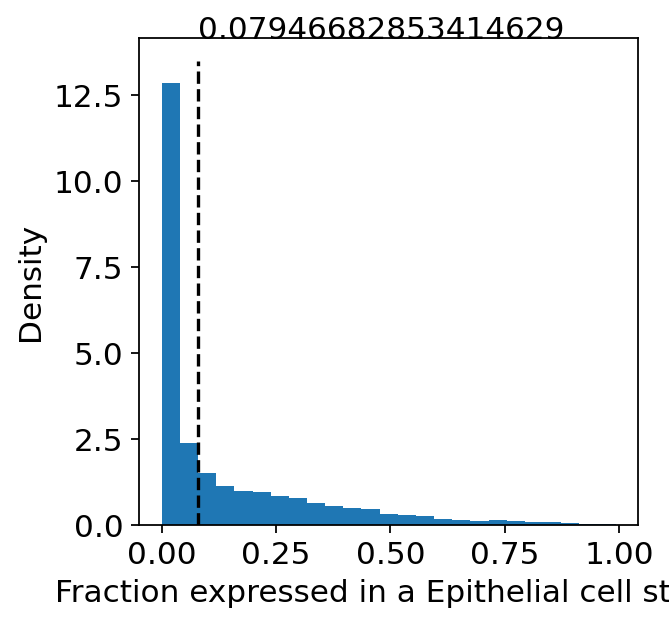

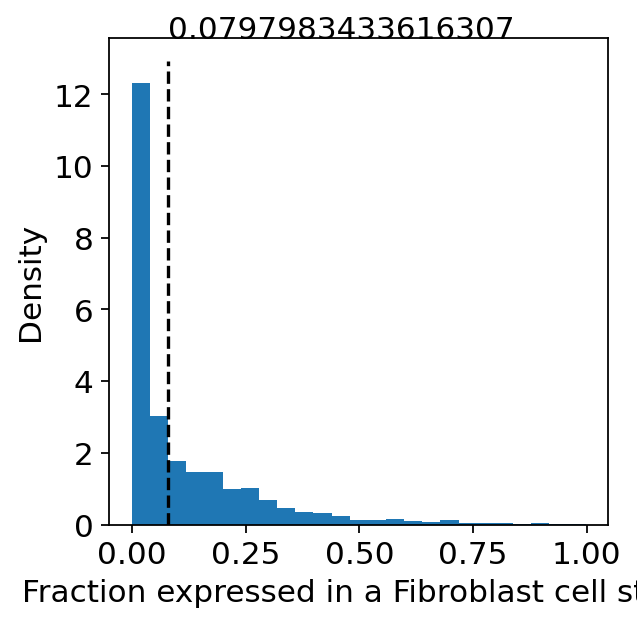

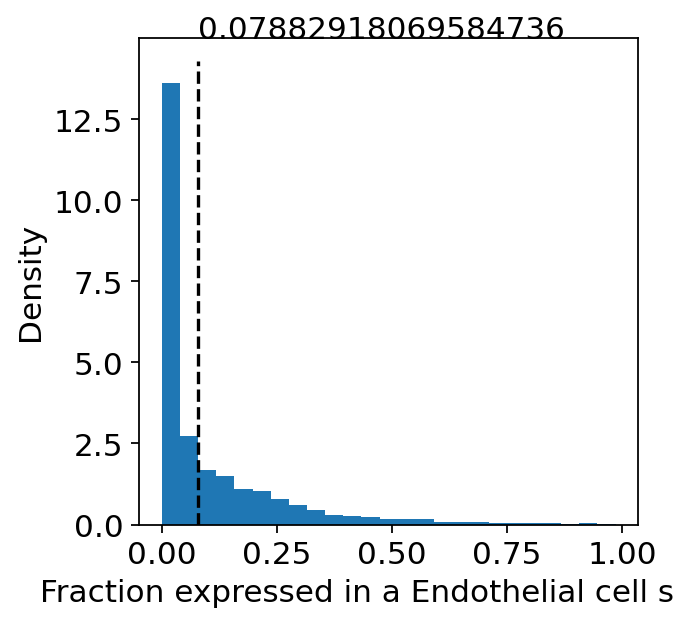

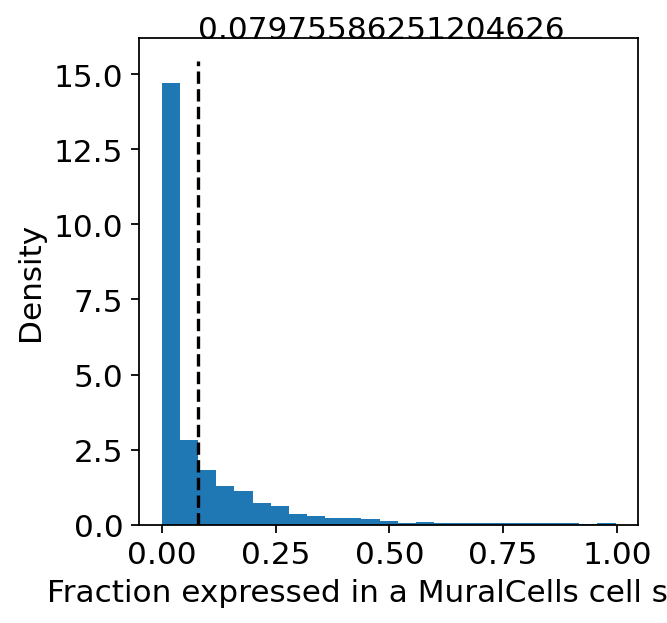

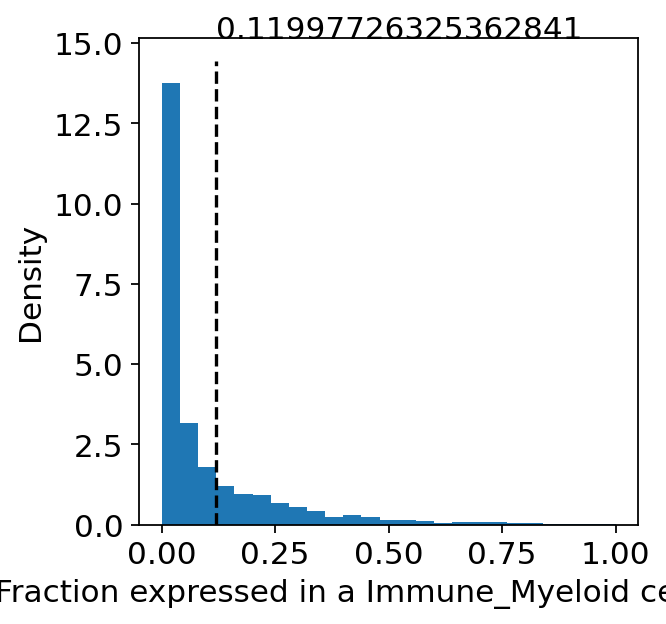

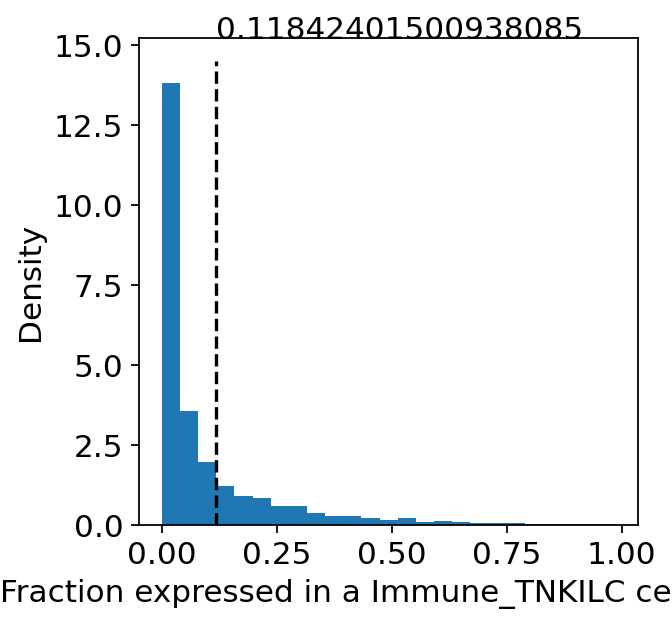

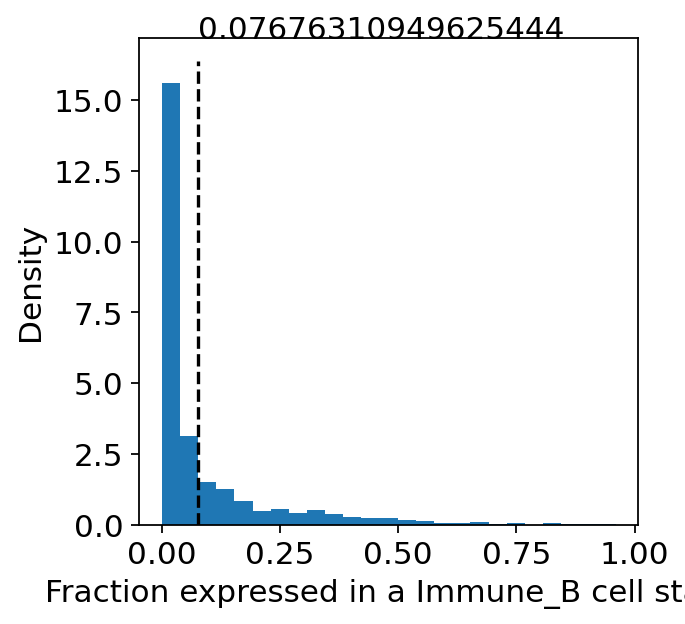

In [ ]:
valid_genes_per_compartment = {}
save_hist = False

for my_compartment in subset_dictionary.keys():
    # Valid genes should be expressed in at least 1% in dissociated cells in the reference dataset
    current_whitelist = gene_whitelist.var_names[np.ravel(gene_whitelist[my_compartment].X.todense()) > 0]
    valid_genes = adata_sub.var_names[ismember(adata_sub.var_names, current_whitelist)[1]].to_numpy()
    # Valid genes should be expressed in at least 10% of a subtype within the compartment
    selected_cells = ismember(adata_sub.obs['cell_type_0'], subset_dictionary[my_compartment])[1]
    selected_subtypes = np.unique(adata_sub.obs['cell_type_1'][selected_cells])
    # Plot distribution
    f = plt.figure()
    h = plt.hist(np.ravel(df_fraction_normalized.loc[selected_subtypes,:].to_numpy()), 25, density = True)
    plt.xlabel('Fraction expressed in a ' + my_compartment + ' cell state')
    detection_rate_threshold = threshold_triangle(h[0], h[1])
    plt.plot([detection_rate_threshold] * 2, plt.gca().get_ylim(), 'k--')
    plt.text(detection_rate_threshold, np.max(plt.gca().get_ylim()), str(detection_rate_threshold))
    plt.ylabel('Density')
    if(save_hist):
        plt.savefig('Figures/Fig20251013_revisions_fraction_expressed_cell_states_normalized_counts_'+ my_compartment +'.pdf')
    binarized_fractions = (df_fraction_normalized.loc[selected_subtypes,:] >= detection_rate_threshold).sum(axis=0) > 0
    binarized_fractions = binarized_fractions[binarized_fractions].index.to_numpy()
    valid_genes_per_compartment[my_compartment] = np.array(list(np.intersect1d(valid_genes, binarized_fractions)) + ['ENSMUST00000060501', 'ENSMUST00000107131'])


### Bin gastric-progenitor DC

Identify valid neighborhoods, those that have at least n (n=10) gastric or progenitor cells.
It is important to flag these neighborhoods, but not to subset them, as a subsetting operation can remove epithelial neighbors form neighborhoods that do pass the filtering criterion.

Then, bin neighborhoods according to a continuous variable. I bin in two steps:
1. I select a coarse bin that will help me control for differences in cell state abundance along the gastric progenitor continuum.
2. I select a finer bin to construct niche expression trends.

In [ ]:
adata_original = adata_sub.copy()

In [ ]:
adata_sub = adata_original.copy()

In [ ]:
obs_to_bin = 'progenitor_neighborhood_score'

# Filter cells to exclude neighborhoods with few epithelial cells that may introduce noise

min_valid_epithelial = np.min([np.round(np.mean(adata_sub.obs['count_valid_epithelial'])), 10])
print('Mininum valid epithelial cells: %d' % (min_valid_epithelial))

valid_obs = np.logical_not(np.isnan(adata_sub.obs[obs_to_bin]))
valid_obs = np.logical_and(valid_obs, adata_sub.obs['count_valid_epithelial'] > min_valid_epithelial)

nbins = 100
breaks = np.quantile(adata_sub.obs[obs_to_bin][valid_obs], np.linspace(start=0, stop=1, num=nbins+1))
breaks[-1] = breaks[-1]* 1.1

obs_digitized = np.digitize(adata_sub.obs[obs_to_bin], breaks)

obs_axis = np.array([np.nan] * adata_sub.n_obs)
obs_axis[valid_obs] = obs_digitized[valid_obs]
adata_sub.obs['binned_obs'] = obs_axis.copy()


Mininum valid epithelial cells: 10


### Get inflection point of cell frequencies

Text(0, 0.5, 'Fraction of epithelial')

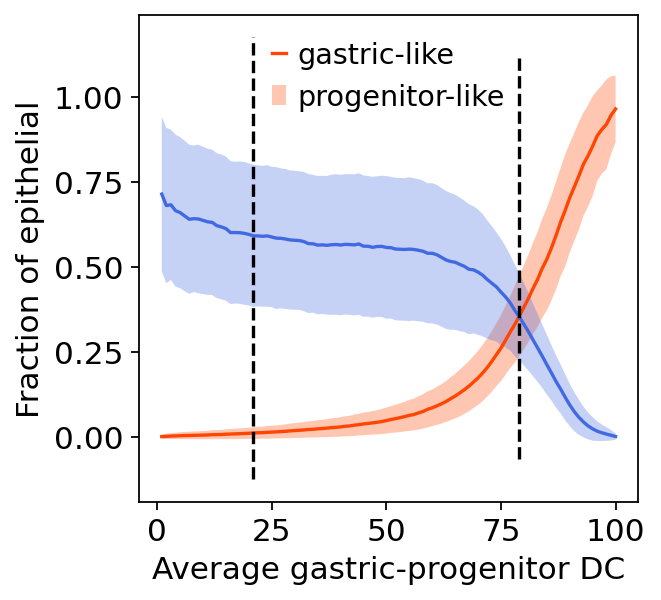

In [ ]:
gastric_progenitor_fraction_per_bin = adata_sub.obs[['gastric_fraction', 'progenitor_fraction', 'binned_obs']].groupby('binned_obs').agg('mean')
summarized_median = adata_sub.obs[['gastric_fraction', 'progenitor_fraction', 'binned_obs']].groupby('binned_obs').agg(lambda x: np.median(x))
summarized_q25 = adata_sub.obs[['gastric_fraction', 'progenitor_fraction', 'binned_obs']].groupby('binned_obs').agg(lambda x: np.quantile(x, 0.25))
summarized_q75 = adata_sub.obs[['gastric_fraction', 'progenitor_fraction', 'binned_obs']].groupby('binned_obs').agg(lambda x: np.quantile(x, 0.25))
summarized_std = adata_sub.obs[['gastric_fraction', 'progenitor_fraction', 'binned_obs']].groupby('binned_obs').agg(lambda x: np.std(x))
summarized_mean = gastric_progenitor_fraction_per_bin
progenitor_threshold = np.min(np.where(gastric_progenitor_fraction_per_bin['gastric_fraction'] < gastric_progenitor_fraction_per_bin['progenitor_fraction'])[0]) + 1
gastric_threshold = (gastric_progenitor_fraction_per_bin.shape[0]) - progenitor_threshold

selected_column = 'progenitor_fraction'
plt.plot(summarized_mean.index, summarized_mean[selected_column], 'orangered')
plt.fill_between(
    summarized_mean.index, summarized_mean[selected_column] - summarized_std[selected_column], 
    summarized_mean[selected_column] + summarized_std[selected_column], alpha=0.3, 
    color='orangered', edgecolor='None', label='Confidence Interval')

selected_column = 'gastric_fraction'
plt.plot(summarized_mean.index, summarized_mean[selected_column], 'royalblue')
plt.fill_between(
    summarized_mean.index, summarized_mean[selected_column] - summarized_std[selected_column], 
    summarized_mean[selected_column] + summarized_std[selected_column], alpha=0.3, 
    color='royalblue', edgecolor='None', label='Confidence Interval')

plt.plot([progenitor_threshold] * 2, plt.gca().get_ylim(), 'k--')
plt.plot([gastric_threshold] * 2, plt.gca().get_ylim(), 'k--')
plt.legend(['gastric-like', 'progenitor-like'], frameon=False)
plt.xlabel('Average gastric-progenitor DC')
plt.ylabel('Fraction of epithelial')

In [ ]:
dataset_prefix = dataset_prefix_global

### Compute gene trends over DC

In [ ]:
from sklearn.preprocessing import StandardScaler

def compute_gene_trends(adata, bin_obs, layer, cell_filter = None, gene_filter = None, zscore = 'before_filtering', log1p = True):
    # Prepare cell and gene filters
    if cell_filter is None:
        cell_filter = np.array([True] * adata.n_obs)
    if gene_filter is None:
        gene_filter = np.array([True] * adata.n_vars)
    
    # Prepare expression matrix
    if(layer == 'X'):
        mat = X.copy()
    else:
        mat = adata.layers[layer].copy()
    if scipy.sparse.issparse(mat):
        mat = np.array(mat.todense())

    if log1p:
        mat = np.log1p(mat)

    # Deal with zscoring
    if zscore == 'before_filtering':
        mat = StandardScaler().fit_transform(mat[:,gene_filter])
        mat = mat[cell_filter,:]
    if zscore == 'after_filtering':
        mat = StandardScaler().fit_transform(mat[cell_filter,:][:,gene_filter])
    if zscore == 'no_zscore':
        mat = mat[cell_filter,:][:,gene_filter]

    df = pd.DataFrame(mat, index = adata.obs_names[cell_filter], columns = adata.var_names[gene_filter])
    
    # Set binned observation
    df['binned_obs'] = adata.obs[bin_obs].to_numpy()[cell_filter]

    # Aggregate matrix
    summarized_df_mean = df.groupby('binned_obs').agg('mean')
    summarized_df_median = df.groupby('binned_obs').agg(lambda x: np.quantile(x, 0.5))
    summarized_df_25 = df.groupby('binned_obs').agg(lambda x: np.quantile(x, 0.25))
    summarized_df_75 = df.groupby('binned_obs').agg(lambda x: np.quantile(x, 0.75))
    summarized_df_std = df.groupby('binned_obs').agg(lambda x: np.std(x))
    summarized_count = df.groupby('binned_obs').agg('count')

    result = {
        'mean': summarized_df_mean,
        'median': summarized_df_median,
        'q25': summarized_df_25,
        'q75': summarized_df_75,
        'std': summarized_df_std,
        'count': summarized_count,
    }

    return(result, df)

Xenium_myeloid_measured = [
    'Mafb','Cd163','Ifi205','Lifr','Maf','Gas6',
    'Itgam','Csf1r','Ifitm1','Adgre1','Ifnar1','Lair1',
    'Csf3r','Cxcr2','Vcan','Mmp9','Ccl2','Cd44','Mki67','Skil',
    'Tgfbi','Serpine1','Plaur','Emilin2','Socs3','Cd274','Il18',
    'Csf2rb','Ccr2','Itgax','Plat','Plau', 'Cxcl9', 'Cxcl10', 'Cxcl12']

Xenium_fibroblast_measured = [
    'Dpt','Cxcl12','Tnxb','Rspo1','Lifr','Pdgfra','Gas6','Ngfr',
    'Epha3','Ptch2','Epha4','Gli1','Ptch1','Spry1','Fgfr2','Igf2',
    'Emp1','Postn','Tnc','Serpine1','Tagln','Lox','Plaur','Cdkn2b',
    'Msn','Tgfb1', 'Tgfbr1', 'Pdgfrb', 'Inhbb','Ccn2','Plat', 'Smo', 'Ccn2']

Xenium_epithelial_measured = [
    'Oasl2', 'Irf7', 'Gsta1', 'F5', 'Itga6', 'Shh', 'Elf3', 'Anxa10', 
    'Lgals4', 'Onecut2', 'Wnt5a', 'Itga1', 'Rbpjl', 'Dusp4', 'Dusp6', 
    'Cp', 'Msln', 'Ifngr1', 'Plaur', 'Il18r1', 'Il18rap', 'Lif', 'Msn', 
    'Nes', 'Plat', 'Cdkn2b', 'Cdkn1a', 'Hmga2', 'Piezo2', 'Plau', 'Pdgfb',
    'Serpine1', 'Csf2', 'Tgfb1', 'Tgfb3', 'Dusp5', 'Kras', 'Vim', 'ENSMUST00000060501', 'ENSMUST00000107131'
]

def first_index(v, default = 'first'):
    if(len(v) > 0):
        result = np.min(v)
    elif default == 'first':
        result = 0
    else:
        result = len(v) - 1
    return(result)

def smooth_trends(trends, bandwidth):
    linspace = np.array([list(range(0,trends.shape[0]))] * 2).T
    d = distance.squareform(distance.pdist(linspace))
    kernel = np.exp(-np.power(d,2) / np.power(bandwidth, 2) / 2) / np.sqrt(2*math.pi*bandwidth)
    mat = np.dot(trends.to_numpy().T, kernel).T
    return(pd.DataFrame(mat, index = trends.index, columns = trends.columns))

def order_trends(trends, window_length = 5):
    trends = trends.copy()
    
    # Time of downregulation
    accumulated_reduction = np.cumsum(trends < 0, axis=0)
    DOWN_point = [first_index(np.where(accumulated_reduction.iloc[:,i] > window_length)[0], default = 'first') for i in range(trends.shape[1])]
    ordering = np.argsort(DOWN_point, kind = 'mergesort')    
    trends = trends.iloc[:, ordering].copy()
    
    # Time of upregulation
    accumulated_induction = np.cumsum(trends > 0, axis=0)
    UP_point = [first_index(np.where(accumulated_induction.iloc[:,i] > window_length)[0], default = 'first') for i in range(trends.shape[1])]
    ordering = np.argsort(UP_point, kind = 'mergesort')    
    trends = trends.iloc[:, ordering].copy()

    return(trends.columns.to_numpy())

def plot_gene_trends(trends, selected_genes, vmin = -1, vmax = 1, y_lines = None, reorder_genes = True):
    if(reorder_genes):
        gene_ordering = order_trends(smooth_trends(trends, 3), window_length=10)
        selected_genes = gene_ordering[ismember(gene_ordering, selected_genes)[1]]
        
    gene_ordering = order_trends(smooth_trends(trends, 3), window_length=10)
    selected_genes = gene_ordering[ismember(gene_ordering, selected_genes)[1]]
    
    f = plt.figure(figsize=[3, 0.2*len(selected_genes)])
    im = plt.imshow(trends.loc[:,selected_genes].T, aspect='auto', vmin=vmin, vmax=vmax, cmap='RdBu_r', interpolation = 'None')
    if not y_lines is None:
        for my_line in y_lines:
            plt.plot([my_line, my_line], f.gca().get_ylim(), 'k--')
    plt.yticks(np.array(list(range(len(selected_genes)))), labels = selected_genes)
    plt.xlabel("Gastric Progenitor DC")
    plt.grid(False)
    cb_ax = f.add_axes([1,0.5,0.02,0.25])
    f.colorbar(im,orientation='vertical',cax=cb_ax, fraction=0.01, label='z-score')
    return(trends.loc[:,selected_genes].T)


In [ ]:
os.makedirs("../gene_trends", exist_ok=True)

In [ ]:
output_file = "../gene_trends/adata_tier3_epi_trends_NHOODMODE_" + nhood_suffix + ".pydata"
if not os.path.exists(output_file):
    print("Processing epithelial cells")
    epi_trends, epi_df = compute_gene_trends(
        adata = adata_sub, 
        bin_obs = 'binned_obs', 
        layer = 'epi_normalized', 
        zscore= 'after_filtering',
        cell_filter = np.logical_not(np.isnan(adata_sub.obs['binned_obs'])),
        log1p = True,
        gene_filter = None
    )
    write_object(epi_trends, output_file)
else:
    epi_trends = read_object(output_file)

output_file = "../gene_trends/adata_tier3_fib_trends_NHOODMODE_" + nhood_suffix + ".pydata"
if not os.path.exists(output_file):
    print("Processing fibroblasts")
    fib_trends, fib_df = compute_gene_trends(
        adata = adata_sub, 
        bin_obs = 'binned_obs', 
        layer = 'fib_normalized', 
        zscore= 'after_filtering',
        cell_filter = np.logical_not(np.isnan(adata_sub.obs['binned_obs'])),
        log1p = True,
        gene_filter = None
    )
    write_object(fib_trends, output_file)
else:
    fib_trends = read_object(output_file)

output_file = "../gene_trends/adata_tier3_myeloid_trends_NHOODMODE_" + nhood_suffix + ".pydata"
if not os.path.exists(output_file):
    print("Processing myeloid cells")
    myeloid_trends, myeloid_df = compute_gene_trends(
        adata = adata_sub, 
        bin_obs = 'binned_obs', 
        layer = 'myeloid_normalized', 
        zscore= 'after_filtering',
        cell_filter = np.logical_not(np.isnan(adata_sub.obs['binned_obs'])),
        log1p = True,
        gene_filter = None
    )
    write_object(myeloid_trends, output_file)
else:
    myeloid_trends = read_object(output_file)

In [ ]:
all_trends = {
    'Epithelial': epi_trends,
    'Immune_Myeloid': myeloid_trends,
    'Fibroblast': fib_trends
}

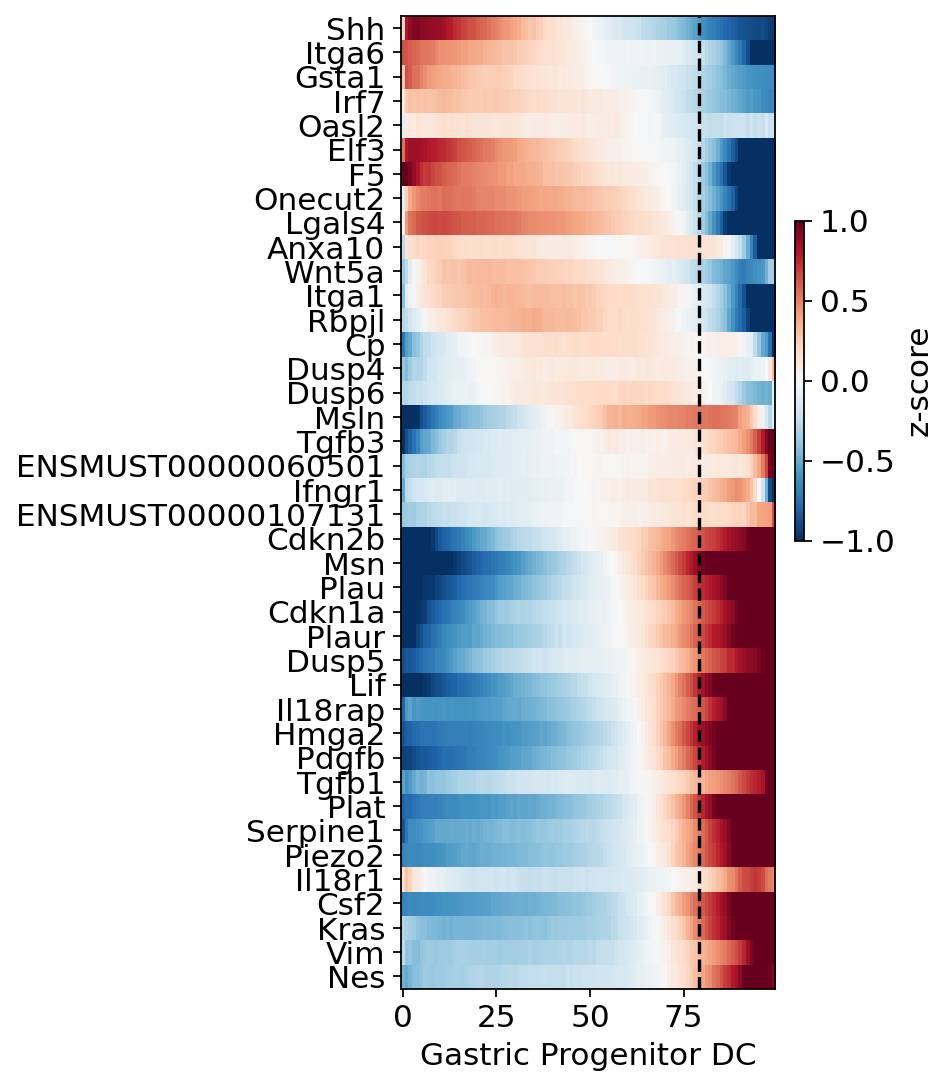

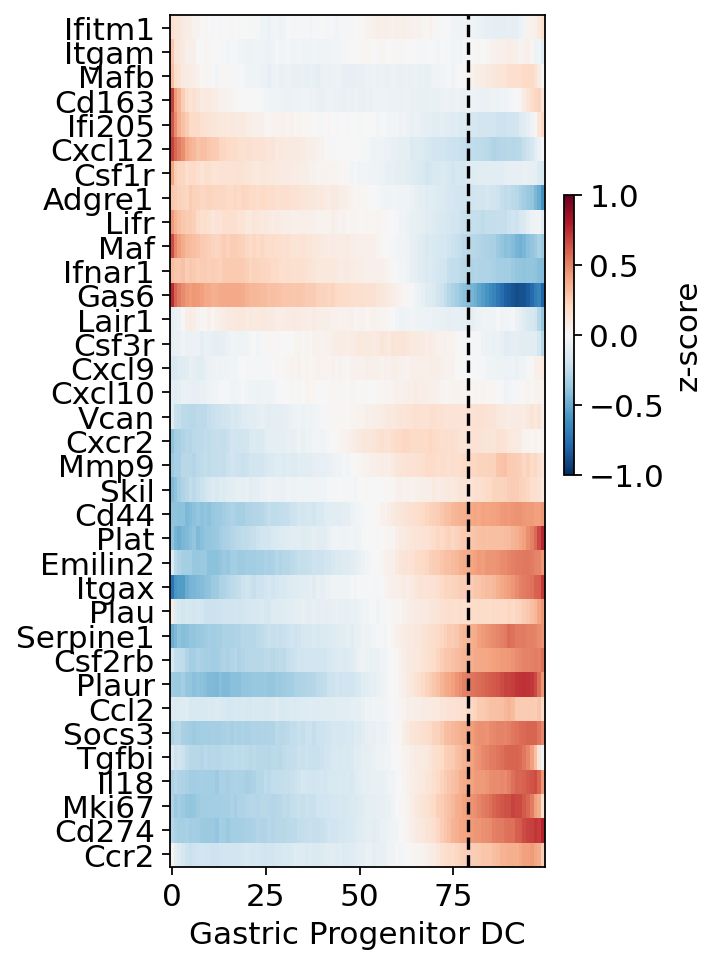

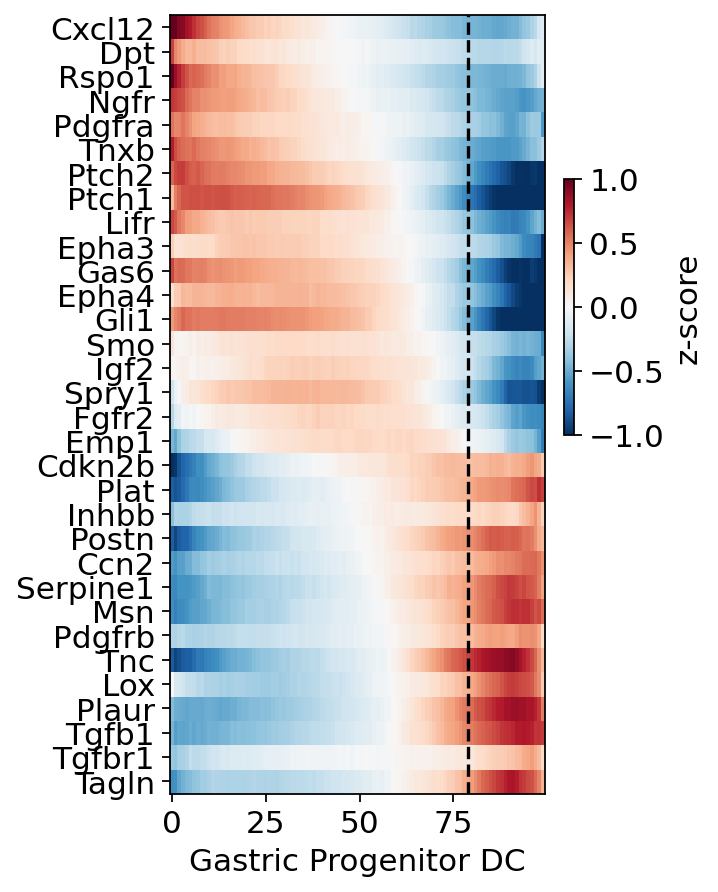

In [ ]:
epi_ordered_genes = plot_gene_trends(epi_trends['mean'], Xenium_epithelial_measured, vmin = -1, vmax = 1, y_lines = [progenitor_threshold])
myeloid_ordered_genes = plot_gene_trends(myeloid_trends['mean'], Xenium_myeloid_measured, vmin = -1, vmax = 1, y_lines = [progenitor_threshold])
fib_ordered_genes = plot_gene_trends(fib_trends['mean'], Xenium_fibroblast_measured, vmin = -1, vmax = 1, y_lines = [progenitor_threshold])


Get correlation of gene trends with the progenitor state

In [ ]:
def get_trend_correlation(trends):
    corr_result = []
    corr_pval = []
    xval = list(range(trends.shape[0]))
    for my_gene in trends.columns:
        result = scipy.stats.spearmanr(xval, trends[my_gene].to_numpy())
        corr_result.append(result.statistic)
        corr_pval.append(result.pvalue)
    df = pd.DataFrame({'statistic': corr_result, 'pval': corr_pval}, index = trends.columns)
    return(df)

def print_full(x):
    pd.set_option('display.max_rows', len(x))
    print(x)
    pd.reset_option('display.max_rows')

In [ ]:
valid_genes = np.intersect1d(communication_genes, valid_genes_per_compartment['Immune_Myeloid'])
myeloid_df = get_trend_correlation(myeloid_trends['mean'].loc[:, valid_genes])
myeloid_df = myeloid_df.loc[myeloid_df['statistic'] > 0.9,:].copy()

In [ ]:
valid_genes = np.intersect1d(communication_genes, valid_genes_per_compartment['Epithelial'])
epithelial_df = get_trend_correlation(epi_trends['mean'].loc[:, valid_genes])
epithelial_df = epithelial_df.loc[epithelial_df['statistic'] > 0.9,:].copy()

In [ ]:
valid_genes = np.intersect1d(communication_genes, valid_genes_per_compartment['Fibroblast'])
fibroblast_df = get_trend_correlation(fib_trends['mean'].loc[:, valid_genes])
fibroblast_df = fibroblast_df.loc[fibroblast_df['statistic'] > 0.9,:].copy()

### Plot trends

In [ ]:
def get_communication_pairs(genes_1, genes_2):
    # Ligands and receptors in clique 1
    ligands_1 = np.intersect1d(genes_1, ligand_receptor_pairs[:,0])
    receptor_1 = np.intersect1d(genes_1, ligand_receptor_pairs[:,1])
    # Ligands and receptors in clique 2
    ligands_2 = np.intersect1d(genes_2, ligand_receptor_pairs[:,0])
    receptor_2 = np.intersect1d(genes_2, ligand_receptor_pairs[:,1])
    # Examine possible receptors for ligands in clique1
    # This fails if ligands_1 is empty
    try:
        cognate_receptor_1 = ligand_receptor_pairs[ismember(ligand_receptor_pairs[:,0], ligands_1)[1],:]
        cognate_receptor_1 = cognate_receptor_1[ismember(cognate_receptor_1[:,1], receptor_2)[1],:]
        LR_direction = {"genes_pairs": ['_'.join(x) for x in cognate_receptor_1]}
    except:
        LR_direction = {}
    # Examine possible ligands for receptors in clique1
    # This fails if receptor_1 is empty
    try:
        cognate_ligands_1 = ligand_receptor_pairs[ismember(ligand_receptor_pairs[:,1], receptor_1)[1],:]
        cognate_ligands_1 = cognate_ligands_1[ismember(cognate_ligands_1[:,0], ligands_2)[1],:]
        RL_direction = {"genes_pairs": ['_'.join(x) for x in cognate_ligands_1]}
    except:
        RL_direction = {}
    return(LR_direction, RL_direction)

def get_communication_pairs(genes_1, genes_2):
    # Ligands and receptors in clique 1
    ligands_1 = np.intersect1d(genes_1, ligand_receptor_pairs[:,0])
    # Ligands and receptors in clique 2
    receptor_2 = np.intersect1d(genes_2, ligand_receptor_pairs[:,1])
    # Examine possible receptors for ligands in clique1
    # This fails if ligands_1 is empty
    try:
        cognate_receptor_1 = ligand_receptor_pairs[ismember(ligand_receptor_pairs[:,0], ligands_1)[1],:]
        cognate_receptor_1 = cognate_receptor_1[ismember(cognate_receptor_1[:,1], receptor_2)[1],:]
        LR_direction = cognate_receptor_1
    except:
        LR_direction = {}
    return(LR_direction)

In [ ]:
def plot_trend(trend1, trend2, df_sizes, colors):
    plt.figure()
    for i, my_color in enumerate(colors):
        size = df_sizes.iloc[:,i].to_numpy() * 500
        plt.scatter(trend1, trend2, s = size, edgecolor='none', color=my_color, alpha = 0.25)

In [ ]:
def plot_all_communication_pairs(cell_type_1, cell_type_2, suffix, save_plot = False):
    package_1 = communication_package[cell_type_1]
    package_2 = communication_package[cell_type_2]
    current_pairs = get_communication_pairs(package_1['genes'], package_2['genes'])
    for i in range(current_pairs.shape[0]):
        ligand = current_pairs[i,0]
        receptor = current_pairs[i,1]
        trend1 = package_1['trends'][ligand]
        trend2 = package_2['trends'][receptor]
        plot_trend(trend1, trend2, gastric_progenitor_fraction_per_bin, ['navy', 'red'])
        current_xlim = plt.gca().get_xlim()
        current_ylim = plt.gca().get_ylim()
        plt.xlim([np.min([-1, current_xlim[0]])*1.1, np.max([1, current_xlim[1]])*1.1])
        plt.ylim([np.min([-1, current_ylim[0]])*1.1, np.max([1, current_ylim[1]])*1.1])
        plt.xlabel(package_1['cell_type'] + " " + ligand + " in niche", fontsize = 17)
        plt.ylabel(package_2['cell_type'] + " " + receptor + " in niche", fontsize = 17)
        plt.xticks(fontsize = 17)
        plt.yticks(fontsize = 17)
        plt.plot([0,0], plt.gca().get_ylim(), 'k--')
        plt.plot(plt.gca().get_xlim(), [0,0], 'k--')
        if save_plot:
            plt.savefig(os.path.join(output_dir, "Figure20250410_LIGAND_%s_%s_RECEPTOR_%s_%s_MODE_spatialAggZscore_GENESET_%s.pdf" % (cell_type_1, ligand, cell_type_2, receptor, suffix)))

In [ ]:
output_dir = 'Figures_crosstalk'
os.makedirs(output_dir, exist_ok=True)
suffix = nhood_suffix

# Select cell-cell communication genes in each compartment
from collections import defaultdict
communication_package = defaultdict(dict)
communication_package['Epithelial'] = {'cell_type': 'epithelial', 'genes': ['Tgfb1', 'Tgfb3', 'Pdgfb', 'Jag1', 'Itgb3', 'Sdc1', 'Lif', 'Csf2', 'Ncam1', 'Acvr1'], 'trends': epi_trends['mean']}
communication_package['Fibroblast'] = {'cell_type': 'fibroblast', 'genes': ['Tgfb1', 'Pdgfrb', 'Notch3', 'Tnc', 'Postn', 'Ccl2', 'Lifr', 'Ncam1', 'Acvr1'], 'trends': fib_trends['mean']}
communication_package['Immune_Myeloid'] = {'cell_type': 'myeloid', 'genes': ['Tgfb1', 'Nrg1', 'Csf2ra', 'Ccr2', 'Acvr1', 'Sdc1'], 'trends': myeloid_trends['mean']}


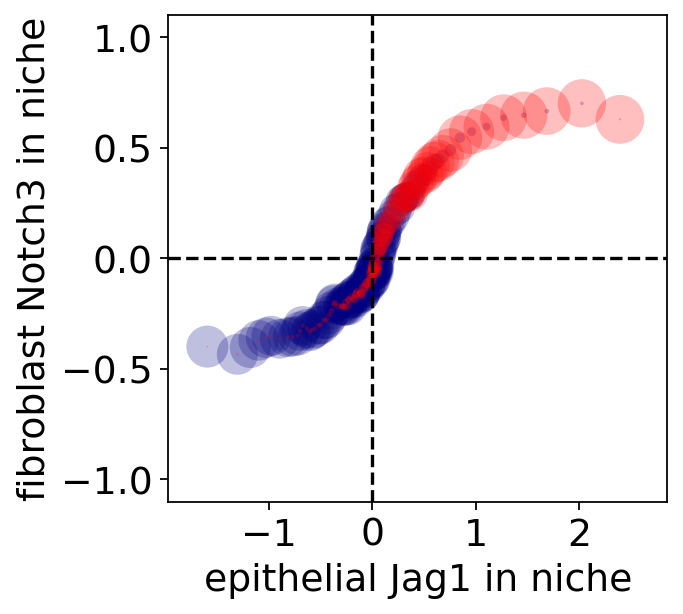

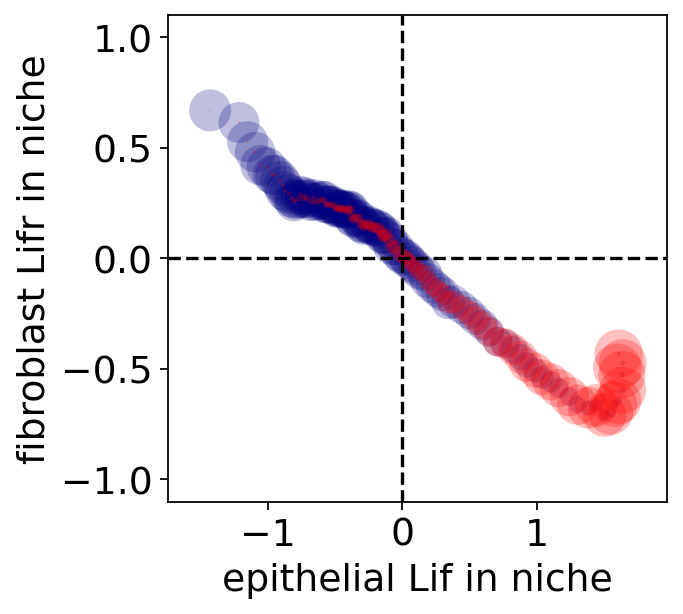

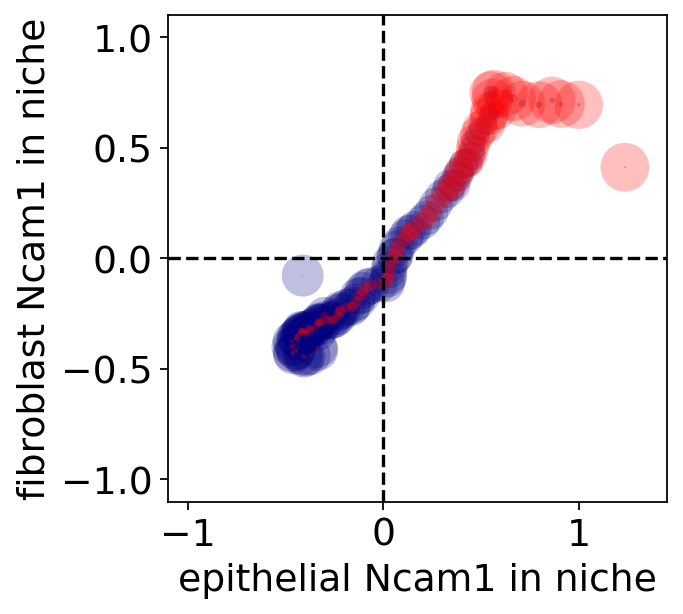

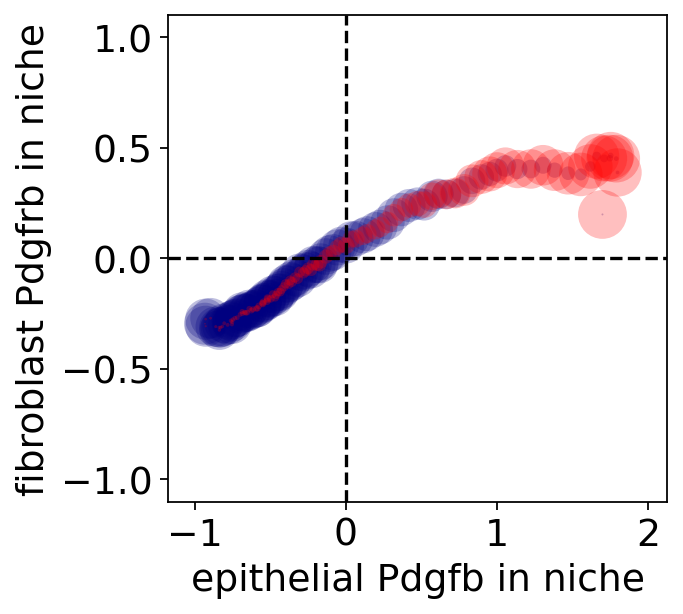

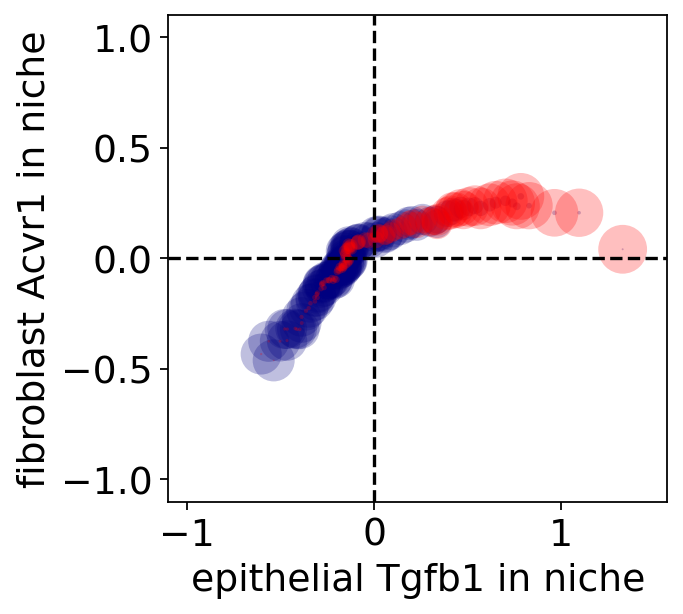

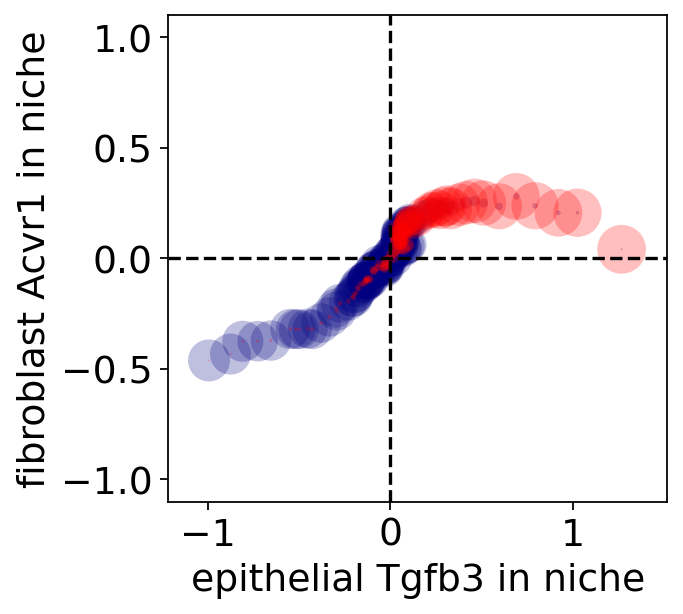

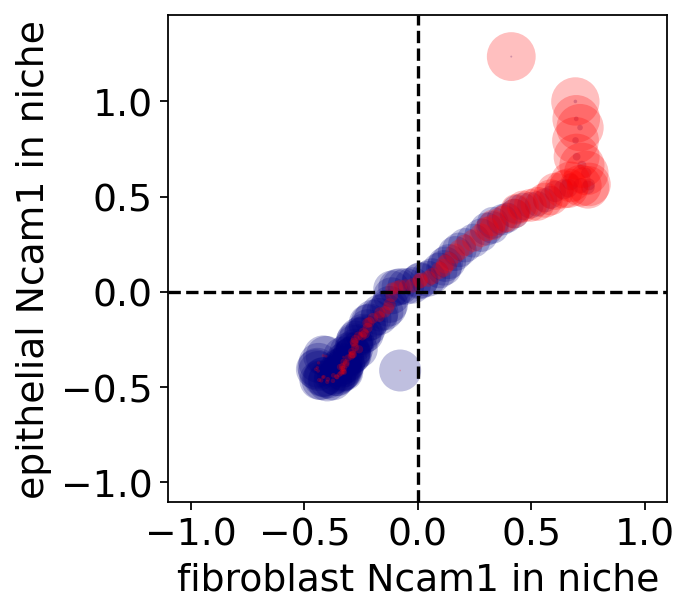

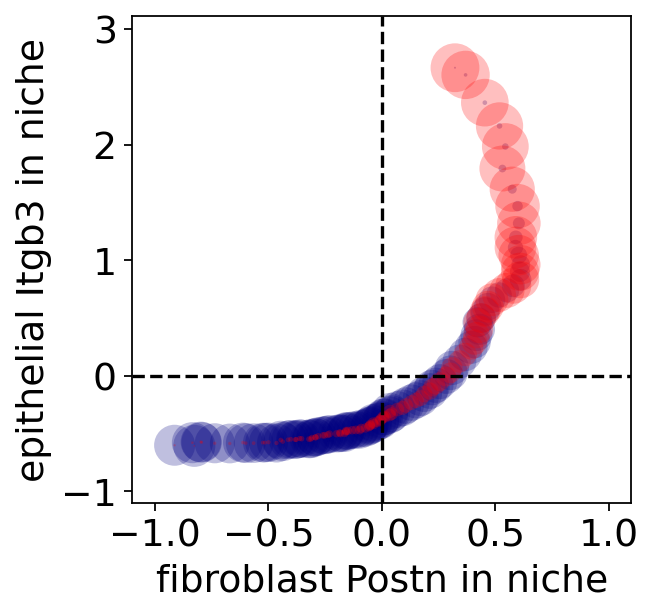

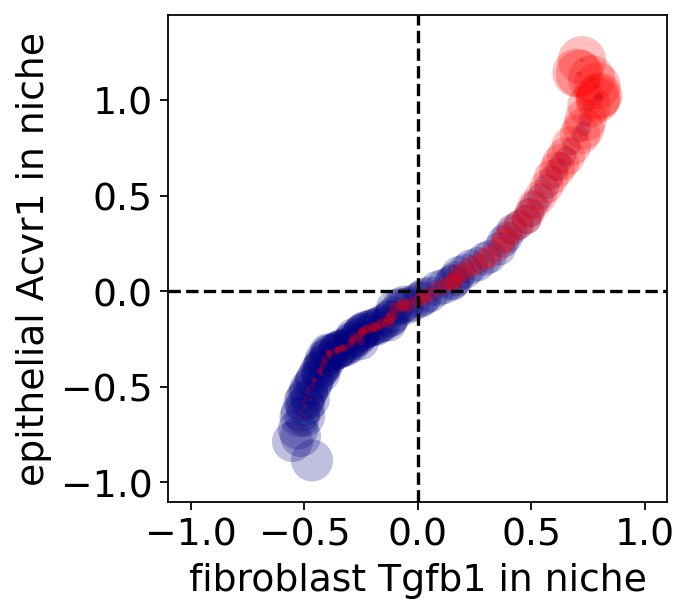

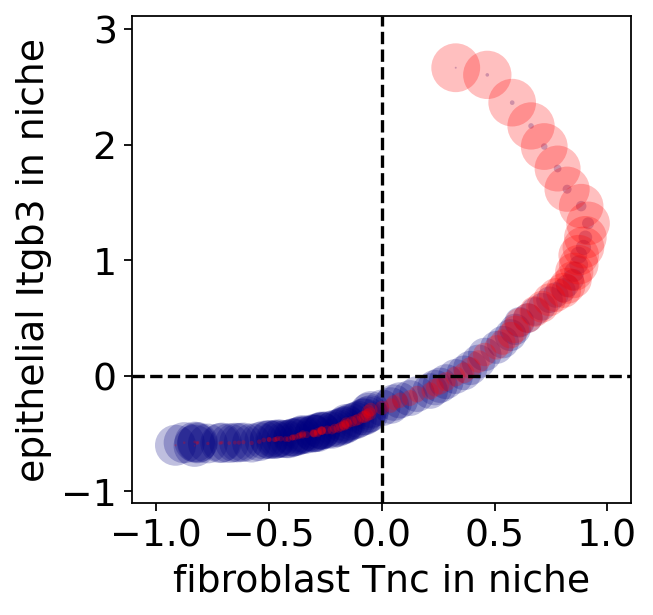

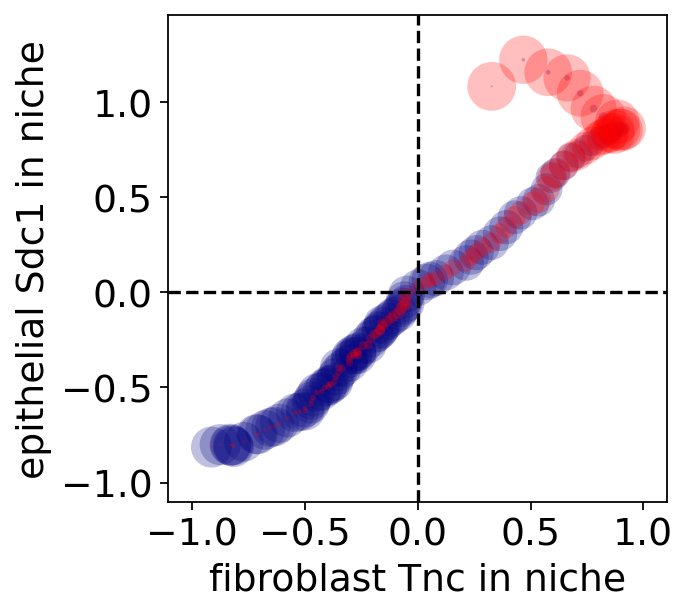

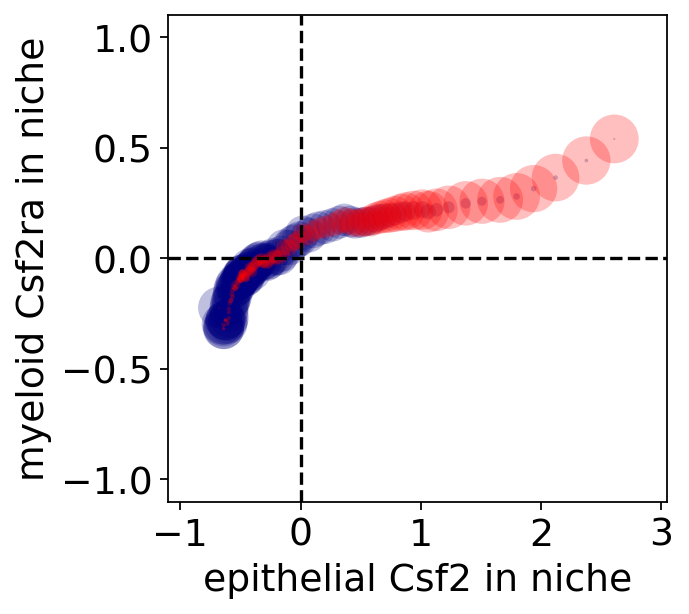

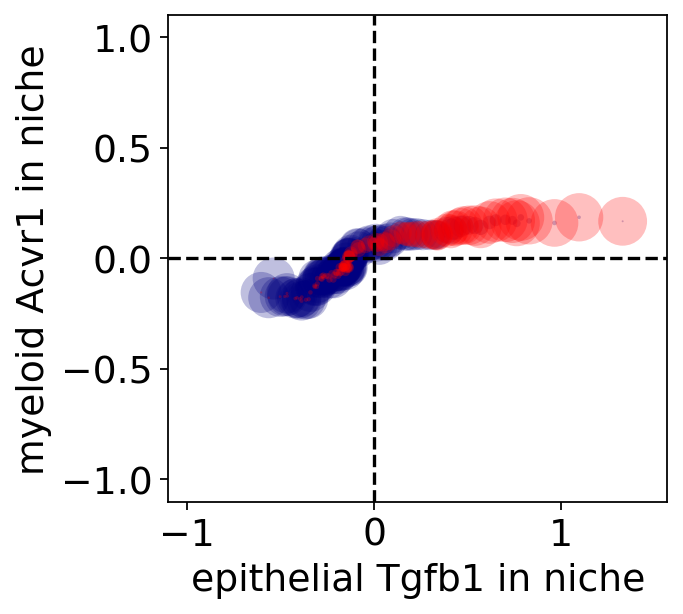

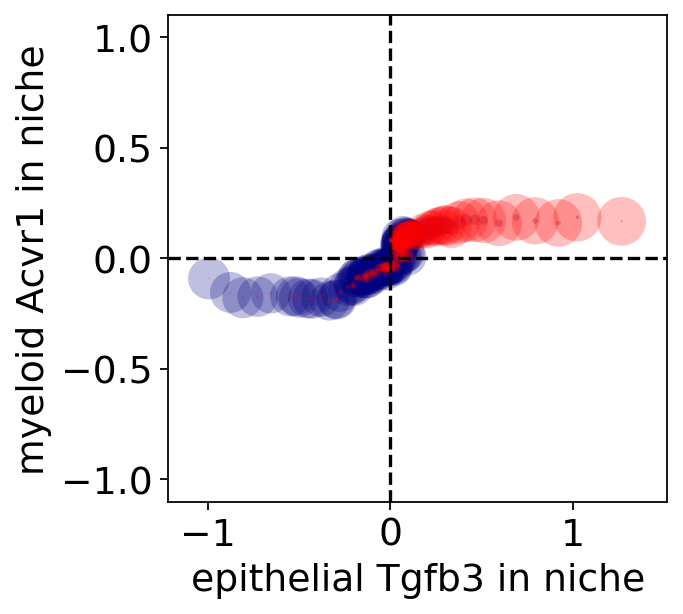

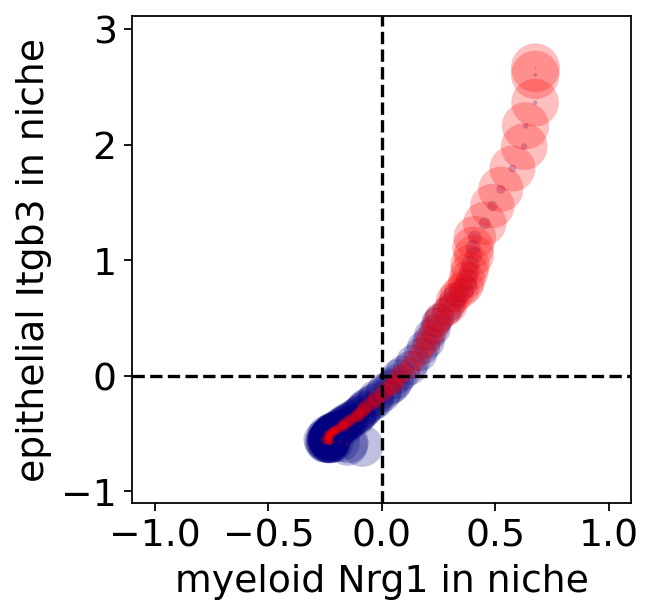

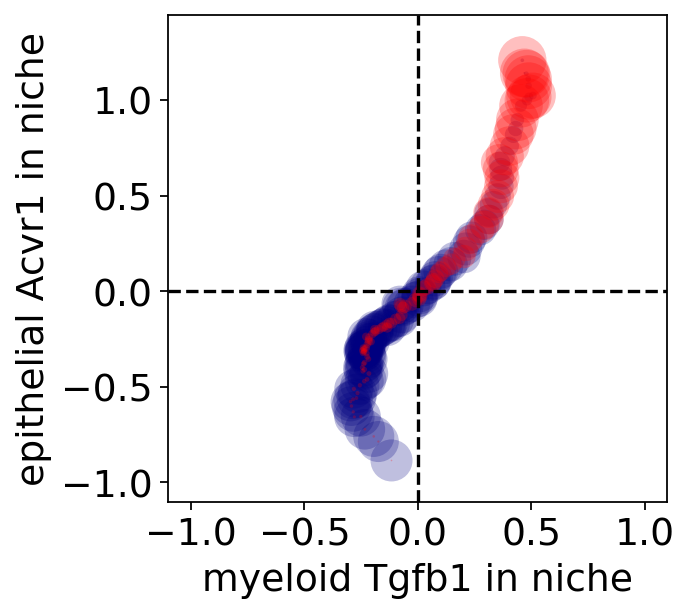

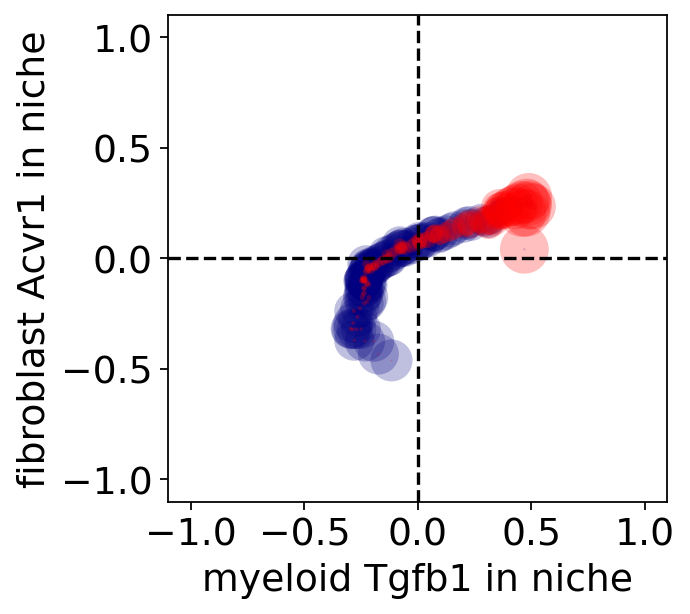

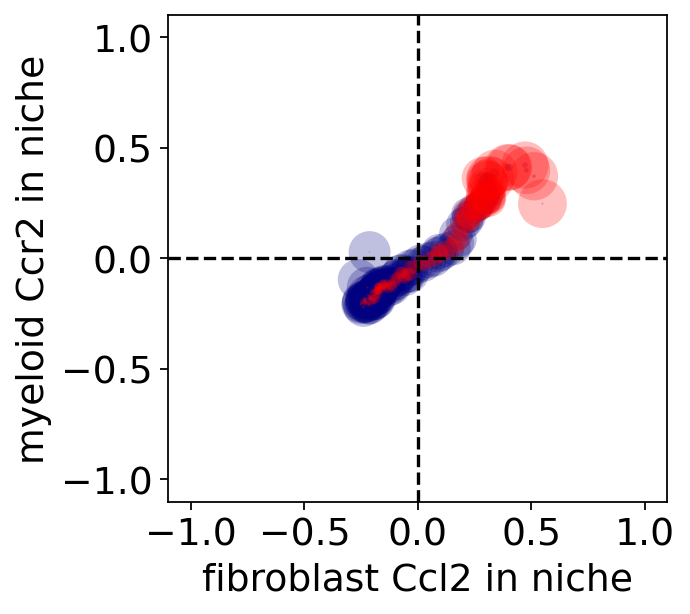

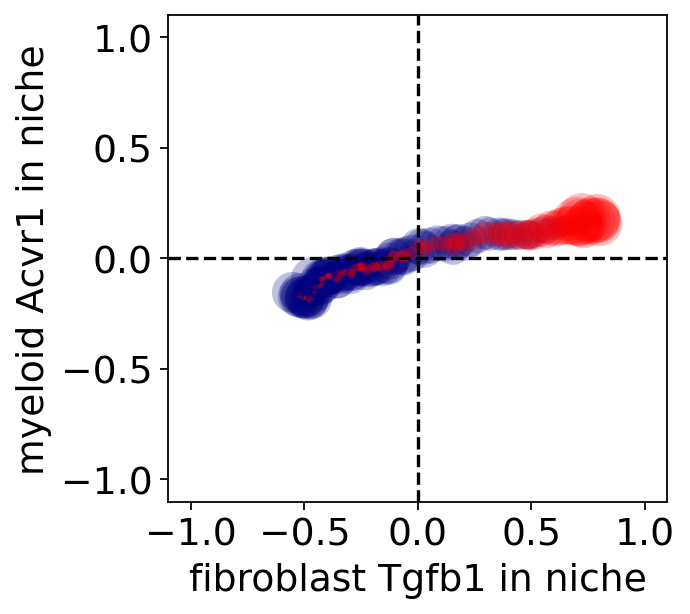

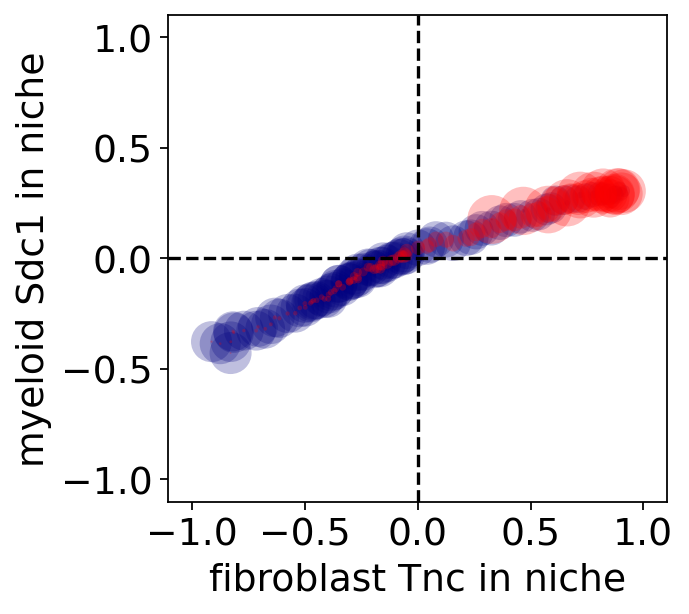

In [ ]:
plot_all_communication_pairs("Epithelial", "Fibroblast", suffix, save_plot=False)
plot_all_communication_pairs("Fibroblast", "Epithelial", suffix, save_plot=False)
plot_all_communication_pairs("Epithelial", "Immune_Myeloid", suffix, save_plot=False)
plot_all_communication_pairs("Immune_Myeloid", "Epithelial", suffix, save_plot=False)
plot_all_communication_pairs("Immune_Myeloid", "Fibroblast", suffix, save_plot=False)
plot_all_communication_pairs("Fibroblast", "Immune_Myeloid", suffix, save_plot=False)

Examples of salient communication axes for Fig 5

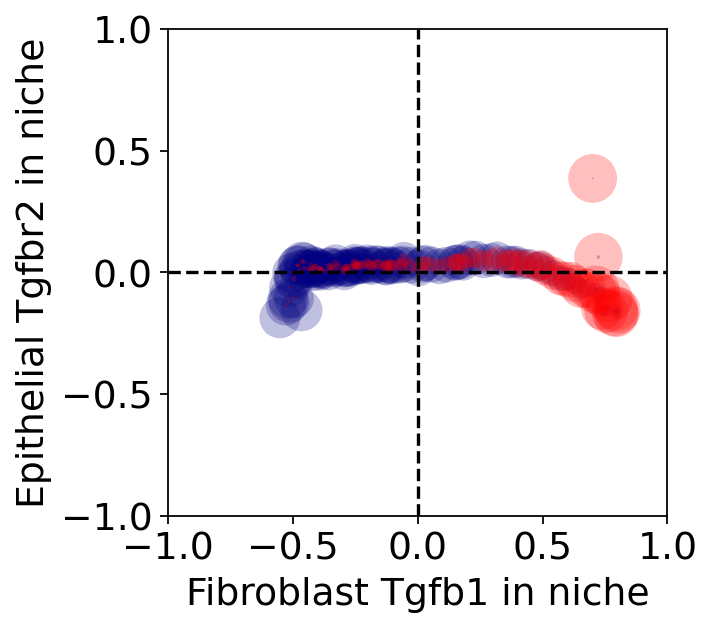

In [ ]:
plot_trend(fib_trends['mean']['Tgfb1'], epi_trends['mean']['Tgfbr2'], gastric_progenitor_fraction_per_bin, ['navy', 'red'])
plt.xticks(fontsize = 17)
plt.yticks(fontsize = 17)
plt.xlabel('Fibroblast Tgfb1 in niche', fontsize = 17)
plt.ylabel('Epithelial Tgfbr2 in niche', fontsize = 17)
plt.xlim([-1, 1])
plt.ylim([-1, 1])

plt.plot([0,0], plt.gca().get_ylim(), 'k--')
plt.plot(plt.gca().get_xlim(), [0,0], 'k--')


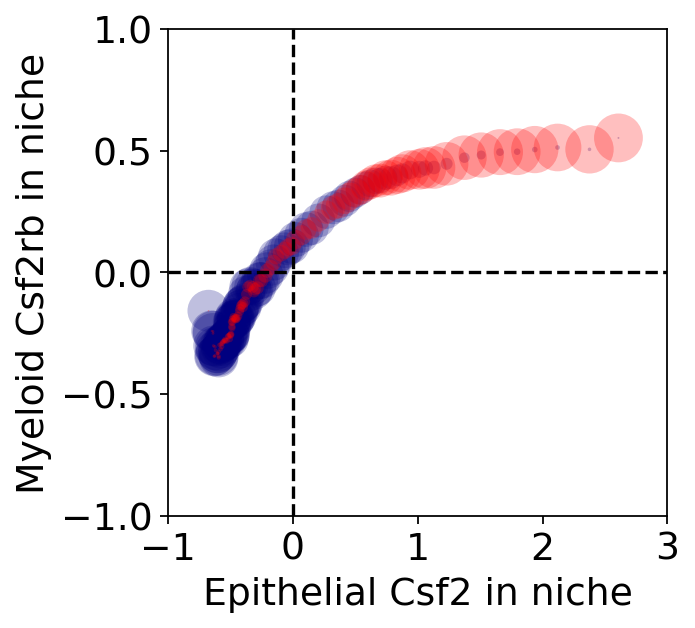

In [ ]:
plot_trend(epi_trends['mean']['Csf2'], myeloid_trends['mean']['Csf2rb'], gastric_progenitor_fraction_per_bin, ['navy', 'red'])
plt.xticks(fontsize = 17)
plt.yticks(fontsize = 17)
plt.xlabel('Epithelial Csf2 in niche', fontsize = 17)
plt.ylabel('Myeloid Csf2rb in niche', fontsize = 17)
plt.xlim([-1, 3])
plt.ylim([-1, 1])

plt.plot([0,0], plt.gca().get_ylim(), 'k--')
plt.plot(plt.gca().get_xlim(), [0,0], 'k--')


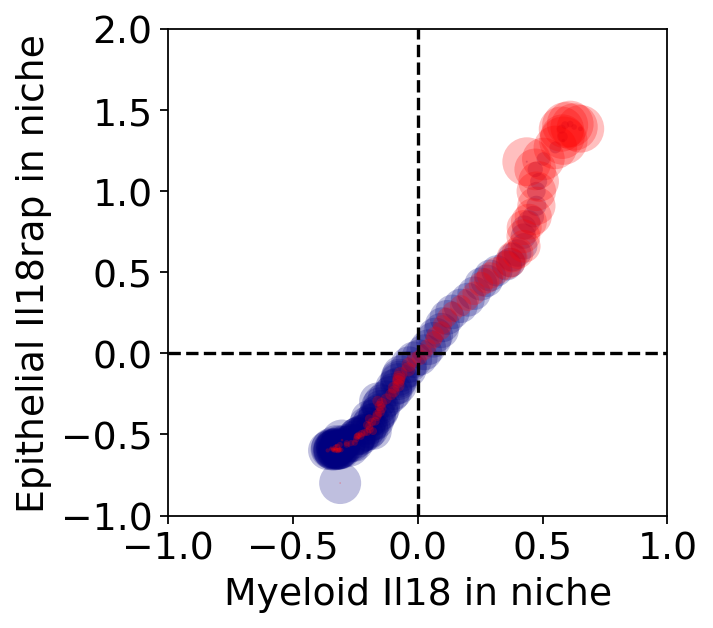

In [ ]:
plot_trend(myeloid_trends['mean']['Il18'], epi_trends['mean']['Il18rap'], gastric_progenitor_fraction_per_bin, ['navy', 'red'])
plt.xticks(fontsize = 17)
plt.yticks(fontsize = 17)
plt.xlabel('Myeloid Il18 in niche', fontsize = 17)
plt.ylabel('Epithelial Il18rap in niche', fontsize = 17)

plt.xlim([-1, 1])
plt.ylim([-1, 2])

plt.plot([0,0], plt.gca().get_ylim(), 'k--')
plt.plot(plt.gca().get_xlim(), [0,0], 'k--')


### Plot representative fields of view

In [ ]:
transcripts_sub = pd.read_csv("../support/Reyes_Xenium_SLIDE_JR0025__transcripts_manuscript_Fig5.csv.gz", index_col = 0)
adata_temp = adata_all[adata_all.obs['slide_id'] == 'JR0025',:].copy()

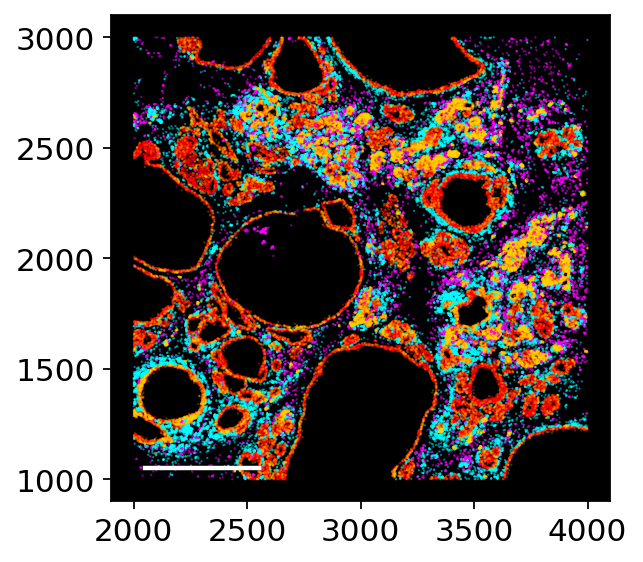

In [ ]:
plt.figure(dpi=80)

plt.scatter(transcripts_sub['x_location'], transcripts_sub['y_location'], color='navy', edgecolor='none', s = 0.1, alpha = 0.05)

feature_filter = ismember(transcripts_sub['feature_name'], ['Cdh1'])[1]
cell_filter = ismember(transcripts_sub['cell_id'], adata_temp.obs['cell_id'][adata_temp.obs['cell_type_0'] == 'Epithelial'])[1]
selected_filter = np.logical_and(feature_filter, cell_filter)
plt.scatter(transcripts_sub['x_location'][selected_filter], transcripts_sub['y_location'][selected_filter], color='red', edgecolor='none', s = 1, alpha = 0.5)

feature_filter = ismember(transcripts_sub['feature_name'], ['Hmga2', 'Nes', 'Msn', 'Vim'])[1]
cell_filter = ismember(transcripts_sub['cell_id'], adata_temp.obs['cell_id'][adata_temp.obs['cell_type_0'] == 'Epithelial'])[1]
selected_filter = np.logical_and(feature_filter, cell_filter)
plt.scatter(transcripts_sub['x_location'][selected_filter], transcripts_sub['y_location'][selected_filter], color='gold', edgecolor='none', s = 1, alpha = 0.25)

feature_filter = ismember(transcripts_sub['feature_name'], ['Tnc'])[1]
cell_filter = ismember(transcripts_sub['cell_id'], adata_temp.obs['cell_id'][adata_temp.obs['cell_type_0'] == 'Fibroblast'])[1]
selected_filter = np.logical_and(feature_filter, cell_filter)
plt.scatter(transcripts_sub['x_location'][selected_filter], transcripts_sub['y_location'][selected_filter], color='cyan', edgecolor='none', s = 1, alpha = 0.5)

feature_filter = ismember(transcripts_sub['feature_name'], ['Itgax', 'Cd274'])[1]
cell_filter = ismember(transcripts_sub['cell_id'], adata_temp.obs['cell_id'][adata_temp.obs['cell_type_0'] == 'Immune_Myeloid'])[1]
selected_filter = np.logical_and(feature_filter, cell_filter)
plt.scatter(transcripts_sub['x_location'][selected_filter], transcripts_sub['y_location'][selected_filter], color='magenta', edgecolor='none', s = 1, alpha = 0.5)

plt.gca().set_facecolor('k')

xlim = plt.gca().get_xlim()
ylim = plt.gca().get_ylim()
plt.plot([xlim[0] + 150, xlim[0] + 150 + 500], [ylim[0] + 150]*2, linewidth = 2, color = 'w')


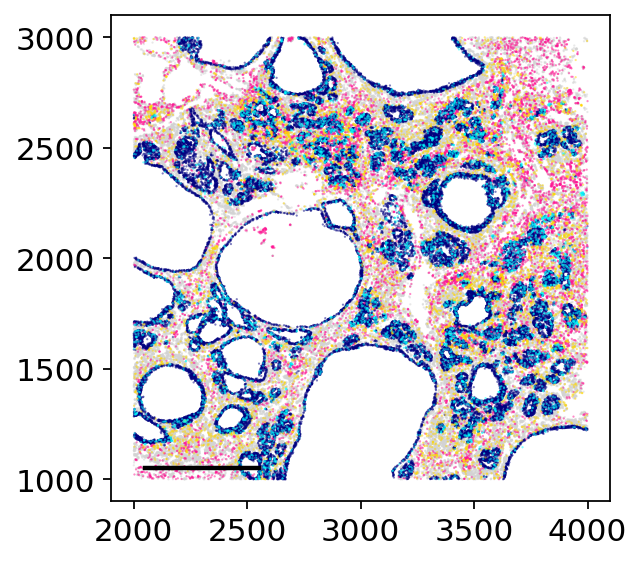

In [ ]:
plt.figure(dpi=80)

#plt.scatter(transcripts_sub['x_location'], transcripts_sub['y_location'], color='navy', edgecolor='none', s = 0.1, alpha = 0.05)

feature_filter = ismember(transcripts_sub['feature_name'], ['Col5a1'])[1]
cell_filter = ismember(transcripts_sub['cell_id'], adata_temp.obs['cell_id'][adata_temp.obs['cell_type_0'] == 'Fibroblast'])[1]
selected_filter = np.logical_and(feature_filter, cell_filter)
plt.scatter(transcripts_sub['x_location'][selected_filter], transcripts_sub['y_location'][selected_filter], color='lightgray', edgecolor='none', s = 1, alpha = 0.5)

feature_filter = ismember(transcripts_sub['feature_name'], ['Csf3r', 'Adgre1'])[1]
cell_filter = ismember(transcripts_sub['cell_id'], adata_temp.obs['cell_id'][adata_temp.obs['cell_type_0'] == 'Immune_Myeloid'])[1]
selected_filter = np.logical_and(feature_filter, cell_filter)
plt.scatter(transcripts_sub['x_location'][selected_filter], transcripts_sub['y_location'][selected_filter], color='lightgray', edgecolor='none', s = 1, alpha = 0.5)

feature_filter = ismember(transcripts_sub['feature_name'], ['Cdh1'])[1]
cell_filter = ismember(transcripts_sub['cell_id'], adata_temp.obs['cell_id'][adata_temp.obs['cell_type_0'] == 'Epithelial'])[1]
selected_filter = np.logical_and(feature_filter, cell_filter)
plt.scatter(transcripts_sub['x_location'][selected_filter], transcripts_sub['y_location'][selected_filter], color='navy', edgecolor='none', s = 1, alpha = 0.5)

feature_filter = ismember(transcripts_sub['feature_name'], ['Tgfb1'])[1]
cell_filter = ismember(transcripts_sub['cell_id'], adata_temp.obs['cell_id'][adata_temp.obs['cell_type_0'] == 'Immune_Myeloid'])[1]
selected_filter = np.logical_and(feature_filter, cell_filter)
plt.scatter(transcripts_sub['x_location'][selected_filter], transcripts_sub['y_location'][selected_filter], color='deeppink', edgecolor='none', s = 1, alpha = 0.5)

feature_filter = ismember(transcripts_sub['feature_name'], ['Tgfb1'])[1]
cell_filter = ismember(transcripts_sub['cell_id'], adata_temp.obs['cell_id'][adata_temp.obs['cell_type_0'] == 'Fibroblast'])[1]
selected_filter = np.logical_and(feature_filter, cell_filter)
plt.scatter(transcripts_sub['x_location'][selected_filter], transcripts_sub['y_location'][selected_filter], color='gold', edgecolor='none', s = 1, alpha = 0.5)

feature_filter = ismember(transcripts_sub['feature_name'], ['Tgfb1'])[1]
cell_filter = ismember(transcripts_sub['cell_id'], adata_temp.obs['cell_id'][adata_temp.obs['cell_type_0'] == 'Epithelial'])[1]
selected_filter = np.logical_and(feature_filter, cell_filter)
plt.scatter(transcripts_sub['x_location'][selected_filter], transcripts_sub['y_location'][selected_filter], color='cyan', edgecolor='none', s = 1, alpha = 0.5)

xlim = plt.gca().get_xlim()
ylim = plt.gca().get_ylim()
plt.plot([xlim[0] + 150, xlim[0] + 150 + 500], [ylim[0] + 150]*2, linewidth = 2, color = 'k')


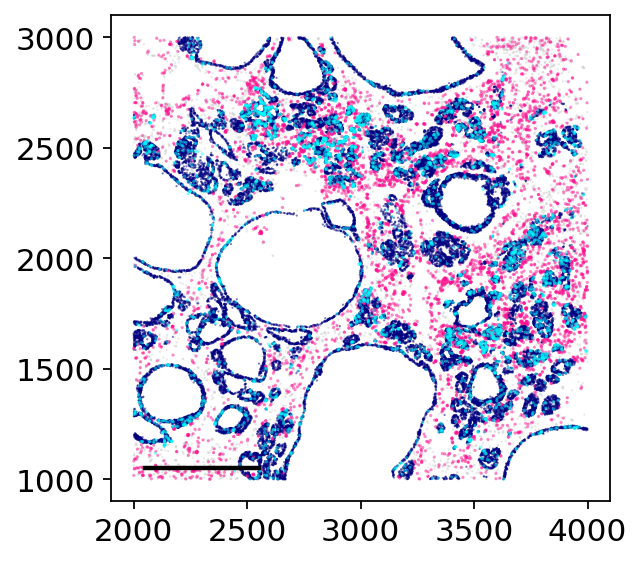

In [ ]:
plt.figure(dpi = 80)

feature_filter = ismember(transcripts_sub['feature_name'], ['Csf1r', 'Adgre1'])[1]
cell_filter = ismember(transcripts_sub['cell_id'], adata_temp.obs['cell_id'][adata_temp.obs['cell_type_0'] == 'Immune_Myeloid'])[1]
selected_filter = np.logical_and(feature_filter, cell_filter)
plt.scatter(transcripts_sub['x_location'][selected_filter], transcripts_sub['y_location'][selected_filter], color='lightgray', edgecolor='none', s = 1, alpha = 0.5)

feature_filter = ismember(transcripts_sub['feature_name'], ['Cdh1'])[1]
cell_filter = ismember(transcripts_sub['cell_id'], adata_temp.obs['cell_id'][adata_temp.obs['cell_type_0'] == 'Epithelial'])[1]
selected_filter = np.logical_and(feature_filter, cell_filter)
plt.scatter(transcripts_sub['x_location'][selected_filter], transcripts_sub['y_location'][selected_filter], color='navy', edgecolor='none', s = 1, alpha = 0.5)

feature_filter = ismember(transcripts_sub['feature_name'], ['Il18'])[1]
cell_filter = ismember(transcripts_sub['cell_id'], adata_temp.obs['cell_id'][adata_temp.obs['cell_type_0'] == 'Immune_Myeloid'])[1]
selected_filter = np.logical_and(feature_filter, cell_filter)
plt.scatter(transcripts_sub['x_location'][selected_filter], transcripts_sub['y_location'][selected_filter], color='deeppink', edgecolor='none', s = 2, alpha = 0.5)

feature_filter = ismember(transcripts_sub['feature_name'], ['Il18rap', 'Il18r1'])[1]
cell_filter = ismember(transcripts_sub['cell_id'], adata_temp.obs['cell_id'][adata_temp.obs['cell_type_0'] == 'Epithelial'])[1]
selected_filter = np.logical_and(feature_filter, cell_filter)
plt.scatter(transcripts_sub['x_location'][selected_filter], transcripts_sub['y_location'][selected_filter], color='cyan', edgecolor='none', s = 2, alpha = 0.5)

xlim = plt.gca().get_xlim()
ylim = plt.gca().get_ylim()
plt.plot([xlim[0] + 150, xlim[0] + 150 + 500], [ylim[0] + 150]*2, linewidth = 2, color = 'k')


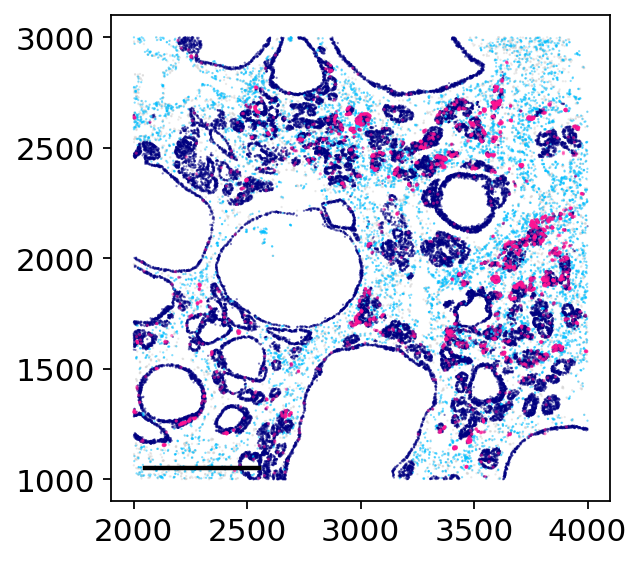

In [ ]:
plt.figure(dpi = 80)

feature_filter = ismember(transcripts_sub['feature_name'], ['Csf1r', 'Adgre1'])[1]
cell_filter = ismember(transcripts_sub['cell_id'], adata_temp.obs['cell_id'][adata_temp.obs['cell_type_0'] == 'Immune_Myeloid'])[1]
selected_filter = np.logical_and(feature_filter, cell_filter)
plt.scatter(transcripts_sub['x_location'][selected_filter], transcripts_sub['y_location'][selected_filter], color='lightgray', edgecolor='none', s = 1, alpha = 0.5)

feature_filter = ismember(transcripts_sub['feature_name'], ['Cdh1'])[1]
cell_filter = ismember(transcripts_sub['cell_id'], adata_temp.obs['cell_id'][adata_temp.obs['cell_type_0'] == 'Epithelial'])[1]
selected_filter = np.logical_and(feature_filter, cell_filter)
plt.scatter(transcripts_sub['x_location'][selected_filter], transcripts_sub['y_location'][selected_filter], color='navy', edgecolor='none', s = 1, alpha = 0.5)

feature_filter = ismember(transcripts_sub['feature_name'], ['Csf2rb'])[1]
cell_filter = ismember(transcripts_sub['cell_id'], adata_temp.obs['cell_id'][adata_temp.obs['cell_type_0'] == 'Immune_Myeloid'])[1]
selected_filter = np.logical_and(feature_filter, cell_filter)
plt.scatter(transcripts_sub['x_location'][selected_filter], transcripts_sub['y_location'][selected_filter], color='deepskyblue', edgecolor='none', s = 1, alpha = 0.5)

feature_filter = ismember(transcripts_sub['feature_name'], ['Csf2'])[1]
cell_filter = ismember(transcripts_sub['cell_id'], adata_temp.obs['cell_id'][adata_temp.obs['cell_type_0'] == 'Epithelial'])[1]
selected_filter = np.logical_and(feature_filter, cell_filter)
plt.scatter(transcripts_sub['x_location'][selected_filter], transcripts_sub['y_location'][selected_filter], color='deeppink', edgecolor='none', s = 2, alpha = 0.5)

xlim = plt.gca().get_xlim()
ylim = plt.gca().get_ylim()
plt.plot([xlim[0] + 150, xlim[0] + 150 + 500], [ylim[0] + 150]*2, linewidth = 2, color = 'k')


### Get distributions of gene expression of a signature

In [ ]:
signature_genes = pd.read_csv('../signatures/GOBP_wound_healing.txt')
genes_in_signature = adata_sub.var_names[ismember([x.upper() for x in adata_sub.var_names], signature_genes['gene_id'].to_numpy())[1]]
genes_in_signature

Index(['Acvrl1', 'Axl', 'Ccn1', 'Cd40', 'Cd40lg', 'Cd44', 'Cdkn1a', 'Ceacam1',
       'Cldn1', 'Col5a1', 'Cx3cl1', 'Cxcr4', 'Elk3', 'Emilin2', 'Ephb2', 'F2r',
       'F3', 'F5', 'Fgf1', 'Fgf2', 'Gas6', 'Gata4', 'Gna13', 'Igf1', 'Il1a',
       'Il6', 'Il6st', 'Itga5', 'Itgb3', 'Itgb5', 'Jak2', 'Jaml', 'Kdr', 'Lck',
       'Lman1', 'Mcam', 'Notch2', 'Notch4', 'Nrg1', 'Pdgfb', 'Pdgfra', 'Pdpn',
       'Plat', 'Plau', 'Plaur', 'Pou2f3', 'Sdc4', 'Selp', 'Serpine1', 'Shh',
       'Smad3', 'Tgfb1', 'Tgfb2', 'Tgfbr1', 'Tnf', 'Tnfrsf12a', 'Vegfa',
       'Wnt4', 'Wnt5a', 'Wnt7a'],
      dtype='object')

In [ ]:
selected_matrices = {
    'Epithelial': 'epi_normalized',
    'Fibroblast': 'fib_normalized',
    'Immune_Myeloid': 'myeloid_normalized'
}
zscore = True

result = []
compartment_names = []
compartment_genes = []
for my_compartment in tqdm(selected_matrices.keys()):
    valid_genes = np.intersect1d(genes_in_signature, valid_genes_per_compartment[my_compartment])
    compartment_genes.append(valid_genes)
    valid_genes = ismember(adata_sub.var_names, valid_genes)[1]
    matrix_sub = np.log1p(np.array(adata_sub.layers[selected_matrices[my_compartment]][:,valid_genes].todense()))
    scaled_data = StandardScaler().fit_transform(matrix_sub)
    result.append(np.ravel(scaled_data.mean(axis=1)))
    compartment_names.append(my_compartment)

df = pd.DataFrame(result).T

100%|██████████| 3/3 [00:20<00:00,  7.00s/it]


In [ ]:
df.index = adata_sub.obs_names
df_original = df.copy()

In [ ]:
niche_filter = adata_sub.obs['count_valid_epithelial'].to_numpy() > 10
df = df_original.loc[niche_filter,:].copy()
sub_niches = np.logical_or(adata_sub.obs['binned_obs'][niche_filter] < gastric_threshold, adata_sub.obs['binned_obs'][niche_filter] > progenitor_threshold)
df_sub = df.loc[sub_niches.to_numpy(),:].copy()
df.columns = compartment_names

In [ ]:
df_sub['progenitor_niche'] = adata_sub[df_sub.index,:].obs['binned_obs'] > progenitor_threshold
df_sub['slide_id'] = adata_sub[df_sub.index,:].obs['slide_id'].to_numpy()

In [ ]:
selected_columns = df_sub.columns[:-2]
result = []
for i in selected_columns:
    df_temp = df_sub.loc[:,[i, 'progenitor_niche', 'slide_id']].copy()
    df_temp.columns = ['score', 'progenitor_niche', 'slide_id']
    df_temp['gene'] = [compartment_names[i]] * df_temp.shape[0]
    result.append(df_temp)
df_vertical = pd.concat(result, axis = 0)
df_vertical

,score,progenitor_niche,slide_id,gene
0004279_Region_1__aacfappf-1,0.613757,False,JR0025,Epithelial
0004279_Region_1__aacfkcll-1,0.483132,False,JR0025,Epithelial
0004279_Region_1__aaeikgkb-1,0.579578,True,JR0025,Epithelial
0004279_Region_1__aaejofhp-1,0.520595,True,JR0025,Epithelial
0004279_Region_1__aaelnlkg-1,0.593378,True,JR0025,Epithelial
...,...,...,...,...
0028094_Region_2__oikakccm-1,0.137202,False,JR-sp-19-10,Immune_Myeloid
0028094_Region_2__oikgkadf-1,0.239403,False,JR-sp-19-10,Immune_Myeloid
0028094_Region_2__oikjkbio-1,0.235911,True,JR-sp-19-10,Immune_Myeloid
0028094_Region_2__oikkfnag-1,0.150829,False,JR-sp-19-10,Immune_Myeloid


In [ ]:
import random
df_temp = df_vertical.iloc[random.sample(set(list(range(df_vertical.shape[0]))), int(df_vertical.shape[0]/100)),:]

/data/lowe/reyesj3/repositories/temp/ipykernel_118347/3717760580.py:2: DeprecationWarning: Sampling from a set deprecated
since Python 3.9 and will be removed in a subsequent version.
  df_temp = df_vertical.iloc[random.sample(set(list(range(df_vertical.shape[0]))), int(df_vertical.shape[0]/100)),:]


In [ ]:
df_temp

,score,progenitor_niche,slide_id,gene
0027846_Region_3__eecnopng-1,-0.046530,False,JR-sp-15-07,Fibroblast
0027845_Region_3__jgjpnnee-1,0.206824,True,JR-sp-15-05,Immune_Myeloid
0015410_Region_4__lhgcfknc-1,0.065864,True,DACE617,Immune_Myeloid
0028094_Region_2__cplkdjgc-1,0.041632,False,JR-sp-19-10,Immune_Myeloid
0027845_Region_3__lhdbmfhc-1,-0.363155,False,JR-sp-15-05,Immune_Myeloid
...,...,...,...,...
0027845_Region_3__leophnfj-1,-0.573937,False,JR-sp-15-05,Immune_Myeloid
0015410_Region_4__dgpfchad-1,0.554872,True,DACE617,Epithelial
0004279_Region_3__hgbbpphm-1,-0.113550,False,JR0104_section2,Immune_Myeloid
0027845_Region_3__bfcebggf-1,0.217507,True,JR-sp-15-05,Immune_Myeloid


In [ ]:
def ranksums(df_sub, column_to_test, column_to_group):
    """
    Assumes that column to group only has two values
    """
    possible_values = np.unique(df_sub[column_to_group])
    v1 = df_sub[column_to_test][df_sub[column_to_group] == possible_values[0]].to_numpy()
    v2 = df_sub[column_to_test][df_sub[column_to_group] == possible_values[1]].to_numpy()
    result = scipy.stats.ranksums(v1, v2).pvalue
    return(result)
    
def process_summarized_df(summarized_df):
    unique_genes = np.unique(summarized_df['gene'])
    pvals = []
    for i in range(len(unique_genes)):
        df_sub = summarized_df.loc[summarized_df['gene'] == unique_genes[i],:]
        pvals.append(ranksums(df_sub, 'score', 'progenitor_niche'))
    return(pvals, unique_genes)

Text(0.5, 1.0, 'GOBP wound healing')

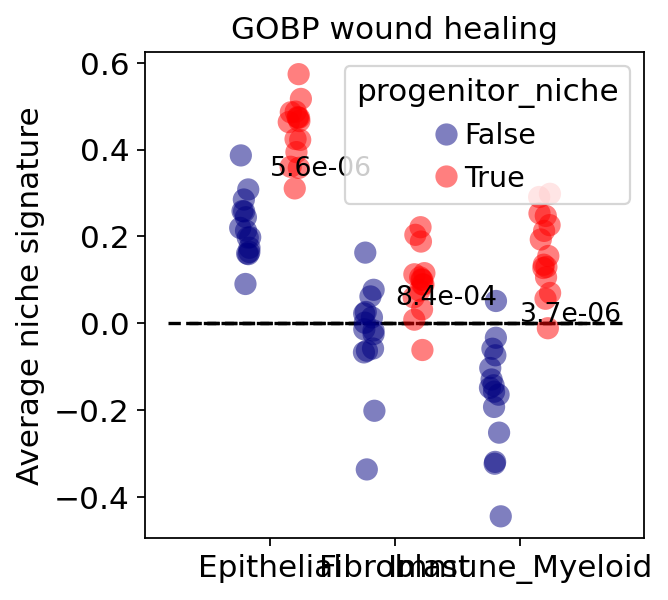

In [ ]:
summarized_df = df_vertical.groupby(['progenitor_niche', 'slide_id', 'gene']).agg('mean').reset_index()
median_df = summarized_df.loc[:,['progenitor_niche', 'gene', 'score']].groupby(['progenitor_niche', 'gene']).agg(lambda x: np.median(x)).reset_index()
center_df = median_df.loc[:,['gene', 'score']].groupby('gene').agg('mean')

sns.stripplot(x = 'gene', y = 'score', hue = 'progenitor_niche', data = summarized_df, dodge = True, palette = ['navy', 'red'], size = 10, alpha = 0.5)
pvals, xlabels = process_summarized_df(summarized_df)
for text, positionx, positiony in zip(pvals, list(range(len(pvals))), center_df['score'].to_numpy()):
    plt.text(positionx, positiony, str("{:.1e}".format(text)), fontsize=12)
    plt.plot(plt.gca().get_xlim(), [0,0], 'k--')
plt.xlabel('')
plt.ylabel("Average niche signature")
plt.title('GOBP wound healing')

In [ ]:
compartment_genes

[array(['Axl', 'Ccn1', 'Cd40', 'Cd44', 'Cdkn1a', 'Ceacam1', 'Col5a1',
        'Cx3cl1', 'Cxcr4', 'Elk3', 'Ephb2', 'F2r', 'F3', 'F5', 'Fgf1',
        'Gas6', 'Gata4', 'Gna13', 'Igf1', 'Il1a', 'Il6st', 'Itga5',
        'Itgb3', 'Itgb5', 'Jak2', 'Lman1', 'Mcam', 'Notch2', 'Notch4',
        'Pdgfb', 'Plat', 'Plau', 'Plaur', 'Sdc4', 'Serpine1', 'Shh',
        'Smad3', 'Tgfb1', 'Tgfbr1', 'Tnfrsf12a', 'Vegfa', 'Wnt4', 'Wnt5a',
        'Wnt7a'], dtype=object),
 array(['Acvrl1', 'Axl', 'Ccn1', 'Cd44', 'Cdkn1a', 'Col5a1', 'Cx3cl1',
        'Cxcr4', 'Elk3', 'Emilin2', 'Ephb2', 'F2r', 'F3', 'Fgf1', 'Fgf2',
        'Gas6', 'Gna13', 'Igf1', 'Il6', 'Il6st', 'Itga5', 'Itgb3', 'Itgb5',
        'Jak2', 'Kdr', 'Lman1', 'Mcam', 'Notch2', 'Pdgfra', 'Pdpn', 'Plat',
        'Plau', 'Plaur', 'Sdc4', 'Serpine1', 'Smad3', 'Tgfb1', 'Tgfb2',
        'Tgfbr1', 'Tnfrsf12a', 'Vegfa', 'Wnt4', 'Wnt5a'], dtype=object),
 array(['Acvrl1', 'Axl', 'Cd40', 'Cd44', 'Cdkn1a', 'Ceacam1', 'Cldn1',
        'Cxcr4', 'Elk3', 'Emil

### Distribution of genes in a single compartment

In [ ]:
selected_genes = compartment_genes[0]
selected_compartments = ['myeloid_normalized']

queries = itertools.product(selected_genes, selected_compartments)
result = []
gene_names = []
compartment_names = []
for my_gene, my_compartment in tqdm(queries):
    result.append(np.log1p(get_gene(adata_sub, my_gene, my_compartment)))
    gene_names.append(my_gene)
    compartment_names.append(my_compartment)
    
df = pd.DataFrame(result)


44it [01:27,  1.99s/it]


In [ ]:
df_original = df.T
df_original.columns = gene_names

In [ ]:
zscore = True

In [ ]:
df_original.index = adata_sub.obs_names
niche_filter = adata_sub.obs['count_valid_epithelial'].to_numpy() > 10
df = df_original.loc[niche_filter,:].copy()
if zscore:
    df = pd.DataFrame(StandardScaler().fit_transform(df.to_numpy()), index = df.index, columns = df.columns)
df['signature_score'] = np.ravel(df.to_numpy().mean(axis=1))


In [ ]:
sub_niches = np.logical_or(adata_sub.obs['binned_obs'][niche_filter] < gastric_threshold, adata_sub.obs['binned_obs'][niche_filter] > progenitor_threshold)
df_sub = df.loc[sub_niches.to_numpy(),:].copy()
df_sub['progenitor_niche'] = adata_sub[df_sub.index,:].obs['binned_obs'] > progenitor_threshold
df_sub['slide_id'] = adata_sub.obs['slide_id']
selected_columns = df_sub.columns[:-2]
result = []
for i in selected_columns:
    df_temp = df_sub.loc[:,[i, 'progenitor_niche', 'slide_id']].copy()
    df_temp.columns = ['score', 'progenitor_niche', 'slide_id']
    df_temp['gene'] = [i] * df_temp.shape[0]
    result.append(df_temp)

In [ ]:
df_vertical = pd.concat(result, axis = 0)
df_vertical

,score,progenitor_niche,slide_id,gene
0004279_Region_1__aacfappf-1,-0.480998,False,JR0025,Axl
0004279_Region_1__aacfkcll-1,-0.613946,False,JR0025,Axl
0004279_Region_1__aaeikgkb-1,-0.623074,True,JR0025,Axl
0004279_Region_1__aaejofhp-1,0.106069,True,JR0025,Axl
0004279_Region_1__aaelnlkg-1,-0.047519,True,JR0025,Axl
...,...,...,...,...
0028094_Region_2__oikakccm-1,0.165448,False,JR-sp-19-10,signature_score
0028094_Region_2__oikgkadf-1,0.161353,False,JR-sp-19-10,signature_score
0028094_Region_2__oikjkbio-1,0.264993,True,JR-sp-19-10,signature_score
0028094_Region_2__oikkfnag-1,-0.045587,False,JR-sp-19-10,signature_score


In [ ]:
import random
df_temp = df_vertical.iloc[random.sample(set(list(range(df_vertical.shape[0]))), int(df_vertical.shape[0]/100)),:]

/data/lowe/reyesj3/repositories/temp/ipykernel_118347/3717760580.py:2: DeprecationWarning: Sampling from a set deprecated
since Python 3.9 and will be removed in a subsequent version.
  df_temp = df_vertical.iloc[random.sample(set(list(range(df_vertical.shape[0]))), int(df_vertical.shape[0]/100)),:]


In [ ]:
summarized_df = df_temp.loc[:,['progenitor_niche', 'gene', 'score']].groupby(['progenitor_niche', 'gene']).agg('mean').reset_index()
summarized_temp = summarized_df.loc[summarized_df['gene'] != 'signature_score',:].copy()
gene_ordering = np.argsort(summarized_temp['score'][summarized_temp['progenitor_niche'] == True].to_numpy() - summarized_temp['score'][summarized_temp['progenitor_niche'] == False].to_numpy())
gene_order = list(summarized_temp['gene'][summarized_temp['progenitor_niche'] == True].to_numpy()[gene_ordering][::-1])
gene_order = ['signature_score'] + gene_order

(-0.5, 21.5)

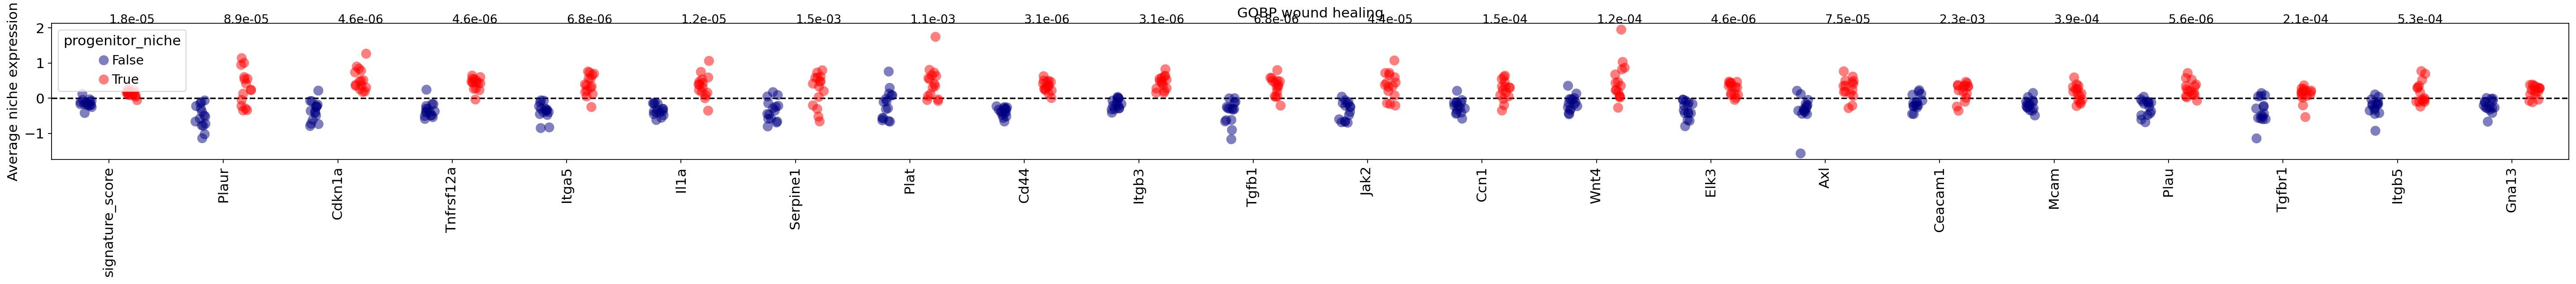

In [ ]:
plt.figure(figsize = [len(gene_order)*1,2.5])

summarized_df = df_vertical.groupby(['progenitor_niche', 'slide_id', 'gene']).agg('mean').reset_index()
median_df = summarized_df.loc[:,['progenitor_niche', 'gene', 'score']].groupby(['progenitor_niche', 'gene']).agg(lambda x: np.median(x)).reset_index()
center_df = median_df.loc[:,['gene', 'score']].groupby('gene').agg('mean')

sns.stripplot(
    x = 'gene', y = 'score', hue = 'progenitor_niche', 
    order = gene_order,
    data = summarized_df, dodge = True, palette = ['navy', 'red'], 
    size = 10, alpha = 0.5)
plt.xticks(rotation=90)

pvals, xlabels = process_summarized_df(summarized_df)
pvals = np.array(pvals)[ismember(gene_order, xlabels)[0]]

max_genes = 21

for text, positionx, positiony in zip(pvals[:max_genes], np.array(list(range(len(pvals))))[:max_genes], center_df['score'].to_numpy()[:max_genes]):
    plt.text(positionx, plt.gca().get_ylim()[1], str("{:.1e}".format(text)), fontsize=12)

plt.plot(plt.gca().get_xlim(), [0,0], 'k--')
plt.xlabel('')
plt.ylabel("Average niche expression")
plt.title('GOBP wound healing')
plt.xlim([-0.5,max_genes + 0.5])


### Get distribution of gene expression for select genes

In [ ]:
selected_genes = ['Tgfbr1', 'Tgfbr2']
selected_compartments = ['epi_normalized', 'fib_normalized', 'myeloid_normalized']
zscore = False

queries = itertools.product(selected_genes, selected_compartments)
result = []
gene_names = []
compartment_names = []
for my_gene, my_compartment in queries:
    result.append(np.log1p(get_gene(adata_sub, my_gene, my_compartment)))
    gene_names.append(my_gene)
    compartment_names.append(my_compartment)
    
df = pd.DataFrame(result)


In [ ]:
df_original = df.T

In [ ]:
df_original.index = adata_sub.obs_names

In [ ]:
niche_filter = adata_sub.obs['count_valid_epithelial'].to_numpy() > 10
df = df_original.loc[niche_filter,:].copy()
if zscore:
    df = pd.DataFrame(StandardScaler().fit_transform(df.to_numpy()), index = df.index)


In [ ]:
sub_niches = np.logical_or(adata_sub.obs['binned_obs'][niche_filter] < gastric_threshold, adata_sub.obs['binned_obs'][niche_filter] > progenitor_threshold)
df_sub = df.loc[sub_niches.to_numpy(),:].copy()

In [ ]:
df_sub.columns = [x + '_' + y for x,y in zip(gene_names, compartment_names)]

In [ ]:
df_sub['progenitor_niche'] = adata_sub[df_sub.index,:].obs['binned_obs'] > progenitor_threshold

In [ ]:
selected_columns = df_sub.columns[:-1]
result = []
for i in selected_columns:
    df_temp = df_sub.loc[:,[i, 'progenitor_niche']].copy()
    df_temp.columns = ['score', 'progenitor_niche']
    df_temp['gene'] = [i] * df_temp.shape[0]
    result.append(df_temp)

In [ ]:
df_vertical = pd.concat(result, axis = 0)
df_vertical

,score,progenitor_niche,gene
0004279_Region_1__aacfappf-1,1.593574,False,Tgfbr1_epi_normalized
0004279_Region_1__aacfkcll-1,1.789711,False,Tgfbr1_epi_normalized
0004279_Region_1__aaeikgkb-1,2.688688,True,Tgfbr1_epi_normalized
0004279_Region_1__aaejofhp-1,3.495520,True,Tgfbr1_epi_normalized
0004279_Region_1__aaelnlkg-1,3.599857,True,Tgfbr1_epi_normalized
...,...,...,...
0028094_Region_2__oikakccm-1,3.274742,False,Tgfbr2_myeloid_normalized
0028094_Region_2__oikgkadf-1,3.311018,False,Tgfbr2_myeloid_normalized
0028094_Region_2__oikjkbio-1,2.903031,True,Tgfbr2_myeloid_normalized
0028094_Region_2__oikkfnag-1,3.190424,False,Tgfbr2_myeloid_normalized


In [ ]:
import random
df_temp = df_vertical.iloc[random.sample(set(list(range(df_vertical.shape[0]))), int(df_vertical.shape[0]/100)),:]

/data/lowe/reyesj3/repositories/temp/ipykernel_118347/3717760580.py:2: DeprecationWarning: Sampling from a set deprecated
since Python 3.9 and will be removed in a subsequent version.
  df_temp = df_vertical.iloc[random.sample(set(list(range(df_vertical.shape[0]))), int(df_vertical.shape[0]/100)),:]


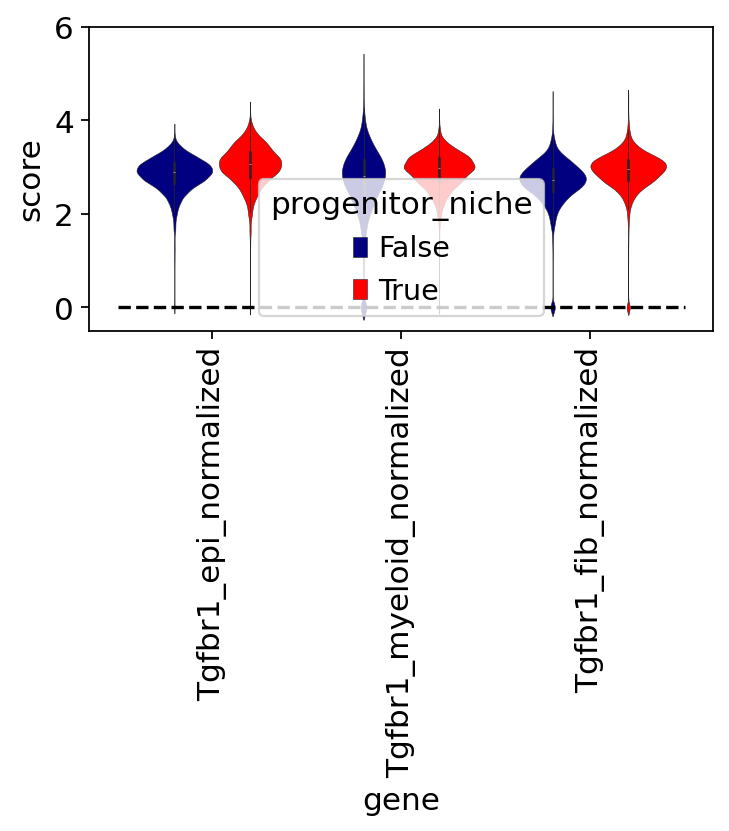

In [ ]:
plt.figure(figsize = [5,2.5])

selected_gene = 'Tgfbr1'

valid_rows = np.array([x.startswith(selected_gene) for x in df_temp['gene']])
sns.violinplot(x = 'gene', y = 'score', hue = 'progenitor_niche', data = df_temp.loc[valid_rows,:], saturation = 1, palette = ['navy', 'red'], linewidth = 0.25)
plt.xticks(rotation=90)
plt.ylim([-0.5,6])
plt.plot(plt.gca().get_xlim(), [0,0], 'k--')

unique_genes = np.unique(df_temp.loc[valid_rows, 'gene'])

In [ ]:
stats.ranksums(
    df_temp.loc[np.logical_and(df_temp['progenitor_niche'] == True, df_temp['gene'] == unique_genes[2]),'score'].to_numpy(), 
    df_temp.loc[np.logical_and(df_temp['progenitor_niche'] == False, df_temp['gene'] == unique_genes[2]),'score'].to_numpy(), 
)


RanksumsResult(statistic=17.582643794649353, pvalue=3.3460396726369697e-69)